# Experts in Teams

## version 1:
$\begin{align}
&\min E(Q,T)=\int_{t_1}^{t_F}\int_\Omega p(t)Q(x,t)\,\mathrm{d}x\mathrm dt+\frac\gamma2\int_\Omega |T(x,t_F)-T_\text{fin}(x)|^2\mathrm dx \\
&\begin{cases}
\rho c\dot T(x,t)&=\nabla\cdot\left(k(x)\nabla T(x,t)\right)+Q(x,t) && \text{in}\ \Omega\times(0,t_F) \\
-k(x)\partial_\nu T(x,t)&=h(x)\left(T(x,t)-T_\text{out}(x,t)\right) && \text{on}\ \partial\Omega\times[0,t_F]\\
T(x,0)=T_\text{ini}(x)&
\end{cases}\tag{SE}\\
& Q\in U_\text{ad}=\{Q\in L^2(\Omega\times(0,t_F))\,|\,0\leq Q(x,t)\leq Q_\text{max}(x)\ \text{a.e.}\}\\
&\text{optional}:\ T(x,t_F)\geq T_\text{fin}(x) (\text{optional if second part of E should be strict})
\end{align}$
where
$T(x,t)$ temperature in K (Henning: I will use °C, but written K is better), $Q(x,t)$ heating output in $\frac W {m^3}$, $p(t)$ price, $\rho$ density in $\frac{kg}{m^3}$, $c$ heat capacity in $\frac{J}{kg\cdot K}$, $k(x)$ heat transfer coefficient in $\frac W{m\cdot K}$, $h(x)$ convective heat transfer coefficient in $\frac W{m^2K}$, $t_1$ morning start time

Remember that $\partial_\nu T$ is the outer normal derivative with respect to $x$ and any initial data (or end data) would have to satisfy the PDE.

In order to solve the (SE) we will use a more basic method, in which we seperate between the spacial and temporal derivatives and first solve the PDE in space using approximations of the time derivatives and then the ODE in time or we try to decouple both variables as much as possible to get a linear system in block structure. This is done by Gridap automatically. Thus, we need the weak formulation only in space (so a semi-weak formulation of the whole system). Here we will give it in its weak form remarking that every time integral of the (WF) for the (SWF) would be replaced by "for all $t\in(0,t_F)$", because computing the derivative of the energy functional is easier this way without loosing track of the $t$, and get with the test space $H^1_{\Gamma}(\Omega\times(0,t_F))$ where $\Gamma=\Omega\times\{0\}$
$\begin{align}
\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot T(x,t)\phi(x,t)\,\mathrm dx\mathrm dt&=\int\limits_0^{t_F}\int\limits_\Omega \nabla\cdot(k(x)\nabla T(x,t)) \phi(x,t)+Q(x,t)\phi(x,t)\,\mathrm dx\mathrm dt\\ 
&=\int\limits_0^{t_F}\int\limits_\Omega -k(x)\nabla T(x,t)\cdot\nabla\phi(x,t)+Q(x,t)\phi(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_{\partial\Omega} k(x)\partial_\nu T(y,t) \phi(x,t)\,\mathrm dy\mathrm dt \\
&=\int\limits_0^{t_F}\int\limits_\Omega -k(x)\nabla T(x,t)\cdot\nabla\phi(x,t)+Q(x,t)\phi(x,t)\,\mathrm dx\mathrm dt-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)(T(y,t)-T_\text{out}(y,t)) \phi(x,t)\,\mathrm dy\mathrm dt 
\end{align}$
giving us the weak formulation
$\begin{align}
\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot T(x,t)\phi(x,t)\,\mathrm dx\mathrm dt=\int\limits_0^{t_F}\int\limits_\Omega -k(x)\nabla T(x,t)\cdot\nabla \phi(x,t)+Q(x,t)\phi(x,t)\,\mathrm dx\mathrm dt-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\left(T(y,t)-T_\text{out}(y)\right)\phi(y,t)\,\mathrm dy\mathrm dt \tag{WF}
\end{align}$
and thus
$\begin{align}
&a_\text{SE}(T,\phi)=\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot T(x,t)\phi(x,t)+k(x)\nabla T(x,t)\cdot\nabla \phi(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)T(y,t)\phi(y,t)\,\mathrm dy\mathrm dt,\qquad\qquad\\
&l_\text{SE}(\phi)=\int\limits_0^{t_F}\int\limits_\Omega Q(x,t)\phi(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)T_\text{out}(y)\phi(y,t)\,\mathrm dy\mathrm dt
\end{align}$
Henning: remember that each boundary integral could be rewritten with the Trace operator, might be helpful for the next part. When writing the (SWF) the open interval for $∀ t\in(0,t_F)$ is important.

From the optimisation functional and the (WF) we get the Lagrangian as
$\begin{align}
L(T,q,W)=\int\limits_{t_1}^{t_F}\int\limits_\Omega p(t)Q(x,t)\,\mathrm{d}x\mathrm dt+\frac\gamma2\int\limits_\Omega |T(x,t_F)-T_\text{fin}(x)|^2\mathrm dx+\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot T(x,t)W(x,t)+k(x)\nabla T(x,t)\cdot\nabla W(x,t)-Q(x,t)W(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\left(T(y,t)-T_\text{out}(y)\right)W(y,t)\,\mathrm dy\mathrm dt
\end{align}$
which gives us the weak formulation of the adjoint (AE) as (notice that the second term contains $\dot\psi$ which in the (SWF) would be zero and thus needs to be solved differently: in that case we are actually only looking for the derivative of the $x$ dendent $T$, so that the derivative $\partial_{T(x)}T(x,t)$ does not give 1 but a time dependent function)
$\begin{align}
L_T(T,Q,W)\psi=\gamma\int\limits_\Omega \left(T(x,t_F)-T_\text{fin}(x)\right)\psi(x,t_F)\mathrm dx+\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot \psi(x,t)W(x,t)+k(x)\nabla \psi(x,t)\cdot\nabla W(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\psi(y,t)W(y,t)\,\mathrm dy\mathrm dt
\end{align}$
By Green for any $t\in(0,t_F)$ it is
$\begin{align}
\int\limits_\Omega k(x)\nabla\psi(x,t)\cdot\nabla W(x,t)\,\mathrm dx=-\int\limits_\Omega \nabla\cdot\left(k(x)\nabla W(x,t)\right)\psi(x,t)\,\mathrm dx+\int\limits_{\partial\Omega} k(y)\partial_\nu W(y,t)\psi(y,t)\,\mathrm dy
\end{align}$
and from Green for the $t$ variable (integration by parts) we get
$\begin{align}
\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot \psi(x,t)W(x,t)\,\mathrm dx\mathrm dt=-\int\limits_0^{t_F}\int\limits_\Omega \rho c\psi(x,t)\dot W(x,t)\,\mathrm dx\mathrm dt+\left[\int\limits_\Omega \rho c\psi(x,t)W(x,t)\,\mathrm dx\right]_0^{t_F}=-\int\limits_0^{t_F}\int\limits_\Omega \rho c\psi(x,t)\dot W(x,t)\,\mathrm dx\mathrm dt+\int\limits_\Omega \rho c\psi(x,t_F)W(x,t_F)\,\mathrm dx
\end{align}$
when assuming $W(x,0)=0$ a.e. (because $W$ has to be able to operate as test function for (SE)) and thus $\psi\in H^1_\Gamma(\Omega\times(0,t_F))$. With these it is
$\begin{align}
L_T(T,Q,W)\psi=\gamma\int\limits_\Omega \left(T(x,t_F)-T_\text{fin}(x)\right)\psi(x,t)\mathrm dx-\int\limits_0^{t_F}\int\limits_\Omega \rho c\psi(x,t)\dot W(x,t)+\nabla\cdot\left(k(x)\nabla W(x,t)\right)\psi(x,t)\,\mathrm dx\mathrm dt-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\psi(y,t)W(y,t)-k(y)\partial_\nu W(y,t)\psi(y,t)\,\mathrm dy\mathrm dt+\int\limits_\Omega \rho c\psi(x,t_F)W(x,t_F)\,\mathrm dx
\end{align}$
giving the strong version
$\begin{align}
\begin{cases}
\rho c\dot W(x,t)&=-\nabla\cdot\left(k(x)\nabla W(x,t)\right)&&\text{in}\ \Omega\times(0,t_F) \\
k(y)\partial_\nu W(y,t)&=h(y)W(y,t)&&\text{on}\ \partial\Omega\times[0,t_F] \\
W(x,t_F)&=-\frac{\gamma}{\rho c}\left(T(x,t_F)-T_\text{fin}(x)\right)&&\text{in}\ \Omega
\end{cases}\tag{AE}
\end{align}$
Thus, we can see that the (AE) has to be solved backwards in time. The weak version is
$\begin{align}
\int\limits_0^{t_F}\int\limits_\Omega \rho c\psi(x,t)\dot W(x,t)-k(x)\nabla \psi(x,t)\cdot\nabla W(x,t)\,\mathrm dx\mathrm dt=-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\psi(y,t)W(y,t)\,\mathrm dy\mathrm dt \tag{WAE}
\end{align}$
For the (AE) we have
$\begin{align}
a_\text{AE}(W,\psi)=\int\limits_0^{t_F}\int\limits_\Omega \rho c\psi(x,t)\dot W(x,t)-k(x)\nabla \psi(x,t)\cdot\nabla W(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\psi(y,t)W(y,t)\,\mathrm dy\mathrm dt\qquad\qquad l_\text{AE}(\psi)=0
\end{align}$
Henning: Actually, we get the (AE) by the variation principle and not by differentiation, which does not fully make sense here.

Variation: In order to find the adjoint, we introduce a small variation $\delta T$ of $T$ in the respective space and look at the difference this variation makes on $L$ (this is like computing $L(T_1,Q,W)-L(T_2,Q,W)$, remember that the adjoint is a measure for the sensitivity of the functional with respect to $T$).
$\begin{align}
\delta_TL(T,Q,W)&=\frac\gamma2\int\limits_\Omega \delta_T|T(x,t_F)-T_\text{fin}(x)|^2\mathrm dx+\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot {\delta T}(x,t)W(x,t)-k(x)\nabla \delta T(x,t)\cdot\nabla W(x,t)\,\mathrm dx\mathrm dt-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\left(\delta T(y,t)-T_\text{out}(y)\right)W(y,t)\,\mathrm dy\mathrm dt \\
&=\gamma\int\limits_\Omega (T(x,t_F)-T_\text{fin}(x))\delta T(x,t_F)\mathrm dx-\int\limits_0^{t_F}\int\limits_\Omega \rho c\delta T(x,t)\dot W(x,t)\,\mathrm dx\mathrm dt+\int\limits_\Omega \rho c\delta T(x,t_F)W(x,t_F)\,\mathrm dx
-\int\limits_0^{t_F}\int\limits_\Omega k(x)\nabla \delta T(x,t)\cdot\nabla W(x,t)\,\mathrm dx\mathrm dt-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\left(\delta T(y,t)-T_\text{out}(y)\right)W(y,t)\,\mathrm dy\mathrm dt 
\end{align}$
where we used the same as above and $\delta T(x,0)=0$ because of the initial value condition, which fixes the $T$s there and because the term is linear. Also for the first term we used Taylor giving us $x^2=x_0^2+2x(x-x_0)+o((x-x_0)^2)$, giving us $\delta_x(x-a)^2=(x-a)^2-(x_0-a)^2=2(x-a)(x-x_0)+o(x-x_0)=2(x-a)\delta_x$.

Since the (AE) has to be solved backwards in time, which is not possible with the software we are using (although implementation would be just as is) we introduce $\widetilde W(x,t)=W(x,t_F-t)$. By the (AE) this function satisfies
$\begin{align}
\begin{cases}
\rho c\dot {\widetilde W}(x,t)&=\nabla\cdot\left(k(x)\nabla \widetilde W(x,t)\right)&&\text{in}\ \Omega\times(0,t_F) \\
k(y)\partial_\nu \widetilde W(y,t)&=h(y)\widetilde W(y,t)&&\text{on}\ \partial\Omega\times[0,t_F] \\
\widetilde W(x,0)&=-\frac{\gamma}{\rho c}\left(T(x,t_F)-T_\text{fin}(x)\right)&&\text{in}\ \Omega
\end{cases}\tag{AE'}
\end{align}$
which can now be solved forward in time. The weak version is
$\begin{align}
\int\limits_0^{t_F}\int\limits_\Omega \rho c\psi(x,t)\dot{\widetilde{W}}(x,t)+k(x)\nabla \psi(x,t)\cdot\nabla \widetilde W(x,t)\,\mathrm dx\mathrm dt=\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\psi(y,t)\widetilde W(y,t)\,\mathrm dy\mathrm dt \tag{WAE}
\end{align}$
For the (AE') we have
$\begin{align}
a_\text{AE}(\widetilde W,\psi)=\int\limits_0^{t_F}\int\limits_\Omega \rho c\psi(x,t)\dot {\widetilde W}(x,t)+k(x)\nabla \psi(x,t)\cdot\nabla \widetilde W(x,t)\,\mathrm dx\mathrm dt-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\psi(y,t)\widetilde W(y,t)\,\mathrm dy\mathrm dt\qquad\qquad l_\text{AE}(\psi)=0
\end{align}$
which then gives us the original adjoint as $W(x,t)=\widetilde W(x,t_F-t)$.

Now we introduce the solution operator $S$, which for a given $Q$ gives the solution $T$ of the (SE), so $T=S(Q)$. With this we can introduce the reduced energy functional
$\begin{align}
e(Q)=\int_{t_1}^{t_F}\int_\Omega p(t)Q(x,t)\,\mathrm{d}x\mathrm dt+\frac\gamma2\int_\Omega |S(Q)(x,t_F)-T_\text{fin}(x)|^2\mathrm dx
\end{align}$
In order to find the gradient of $e$ we differentiate it and find by noting that $S$ is linear and therefore has derivative $S'(Q)h=Sh$
$\begin{align}
e'(Q)h&=\int_{t_1}^{t_F}\int_\Omega p(t)h(x,t)\,\mathrm{d}x\mathrm dt+\gamma\int_\Omega (S(Q)(x,t_F)-T_\text{fin}(x))Sh\mathrm dx\\
&=\langle p|h\rangle+\langle S(Q)-T_\text{fin} | Sh\rangle|_{t=t_F}=\langle p|h\rangle+\gamma\langle S^*(S(Q)-T_\text{fin}) | h\rangle|_{t=t_F} \equiv p-\rho cW
\end{align}$
where $S^*$ is the solution operator for (AE) and $W$ is the solution ........ 


## version 2:
$\begin{align}
&\min E(Q,T)=\int_{t_1}^{t_F}\int_\Omega (p(t)Q(x,t))^2\,\mathrm{d}x\mathrm dt+\frac\gamma2\int_\Omega |T(x,t_F)-T_\text{fin}(x)|^2\mathrm dx \\
&\begin{cases}
\rho c\dot T(x,t)&=\nabla\cdot\left(k(x)\nabla T(x,t)\right)+Q(x,t) && \text{in}\ \Omega\times(0,t_F) \\
-k(x)\partial_\nu T(x,t)&=h(x)\left(T(x,t)-T_\text{out}(x,t)\right) && \text{on}\ \partial\Omega\times[0,t_F]\\
T(x,0)=T_\text{ini}(x)&
\end{cases}\tag{SE}\\
& Q\in U_\text{ad}=\{Q\in L^2(\Omega\times(0,t_F))\,|\,0\leq Q(x,t)\leq Q_\text{max}(x)\ \text{a.e.}\}\\
&\text{optional}:\ T(x,t_F)\geq T_\text{fin}(x) (\text{optional if second part of E should be strict})
\end{align}$
In this case everything stays the same but the Lagrangian is
$\begin{align}
L(T,q,W)=\int\limits_{t_1}^{t_F}\int\limits_\Omega (p(t)Q(x,t))^2\,\mathrm{d}x\mathrm dt+\frac\gamma2\int\limits_\Omega |T(x,t_F)-T_\text{fin}(x)|^2\mathrm dx+\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot T(x,t)W(x,t)-k(x)\nabla T(x,t)\cdot\nabla W(x,t)-Q(x,t)W(x,t)\,\mathrm dx\mathrm dt-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\left(T(y,t)-T_\text{out}(y)\right)W(y,t)\,\mathrm dy\mathrm dt
\end{align}$

Now we introduce the solution operator $S$, which for a given $Q$ gives the solution $T$ of the (SE), so $T=S(Q)$. With this we can introduce the reduced energy functional
$\begin{align}
e(Q)=\int_{t_1}^{t_F}\int_\Omega (p(t)Q(x,t))^2\,\mathrm{d}x\mathrm dt+\frac\gamma2\int_\Omega |S(Q)(x,t_F)-T_\text{fin}(x)|^2\mathrm dx
\end{align}$
In order to find the gradient of $e$ we differentiate it and find by noting that $S$ is linear and therefore has derivative $S'(Q)h=Sh$
$\begin{align}
e'(Q)h&=\int_{t_1}^{t_F}\int_\Omega 2p^2(t)Q(x,t)h(x,t)\,\mathrm{d}x\mathrm dt+\gamma\int_\Omega (S(Q)(x,t_F)-T_\text{fin}(x))Sh\mathrm dx\\
&=\langle 2p^2Q|h\rangle+\langle S(Q)-T_\text{fin} | Sh\rangle|_{t=t_F}=2\langle p^2Q|h\rangle+\gamma\langle S^*(S(Q)-T_\text{fin}) | h\rangle|_{t=t_F} \equiv 2p^2Q-\rho cW
\end{align}$



Thus, without box constraints from the condition $e'(Q)=0$ we would get $Q=-\frac{1}{2p^2}W$ and can use the projection of that onto the box for our case (see bang bang).


## Optimal step size

We found out that the gradient of the reduced cost is $\nabla e(Q)=2p^2Q-\rho cW$, so in the gradient descent algorithm we will go into the negative of that direction and we can actually compute the optimal step size. Consider a given iteration $k$ and the computed control $Q_k$, state $T_k$ and adjoint $W_k$. Also let $v_k=-\nabla e(Q)=-(2p^2Q-\rho cW)$, $I=[t_0,t_F]$ and define as the step-length-dependent function we want to minimise in the iteration
$$g(s)=e(Q_k+sv_k)$$
Then we can rewrite
$\begin{align}
g(s)&=e(Q_k+sv_k)\\ 
&=\lVert p(Q_k+sv_k)\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert S(Q_k+sv_k)-T_{text{fin}}\rVert^2_{L^2(Ω)}\big|_{t=t_F} \\ 
&=\lVert pQ_k\rVert^2_{L^2(\Omega\times I)}+2s⟨p^2Q_k,v_k⟩_{L^2(\Omega\times I)}+s^2\lVert pv_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert T_k-T_\text{fin}\rVert^2_{L^2(Ω)}\big|_{t=t_F}+\gamma s⟨T_k-T_\text{fin},Sv_k⟩_{L^2(Ω)}\big|_{t=t_F}+s^2\frac\gamma2\lVert Sv_k\rVert^2_{L^2(Ω)}\big|_{t=t_F} \\ 
&=s^2\Big(\lVert pv_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert Sv_k\rVert^2_{L^2(Ω)}\big|_{t=t_F}\Big)+s\Big(2⟨p^2Q_k,v_k⟩_{L^2(\Omega\times I)}+\gamma ⟨T_k-T_\text{fin},Sv_k⟩_{L^2(Ω)}\big|_{t=t_F}\Big)+1\Big(\lVert pQ_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert T_k-T_\text{fin}\rVert^2_{L^2(Ω)}\big|_{t=t_F}\Big) \\ 
&=s^2\Big(\lVert pv_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert Sv_k\rVert^2_{L^2(Ω)}\big|_{t=t_F}\Big)+s\Big(2⟨p^2Q_k,v_k⟩_{L^2(\Omega\times I)}+\gamma ⟨S^*(T_k-T_\text{fin}),v_k⟩_{L^2(Ω)}\big|_{t=t_F}\Big)+1\Big(\lVert pQ_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert T_k-T_\text{fin}\rVert^2_{L^2(Ω)}\big|_{t=t_F}\Big) \\ 
&=s^2\Big(\lVert pv_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert Sv_k\rVert^2_{L^2(Ω)}\big|_{t=t_F}\Big)+s\Big(2⟨p^2Q_k,v_k⟩_{L^2(\Omega\times I)}+⟨\rho cW_k,v_k⟩_{L^2(Ω)}\big|_{t=t_F}\Big)+1\Big(\lVert pQ_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert T_k-T_\text{fin}\rVert^2_{L^2(Ω)}\big|_{t=t_F}\Big) \\ 
&=s^2\Big(\lVert pv_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert Sv_k\rVert^2_{L^2(Ω)}\big|_{t=t_F}\Big)-s\lVert v_k\rVert^2_{L^2(\Omega\times I)}+1\Big(\lVert pQ_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert T_k-T_\text{fin}\rVert^2_{L^2(Ω)}\big|_{t=t_F}\Big) 
\end{align}$
This is a quadratic function in $s$ and has the minimum in
$$s_\text{min}=\frac{\lVert v_k\rVert^2_{L^2(\Omega\times I)}}{2\left(\lVert pv_k\rVert^2_{L^2(\Omega\times I)}+\frac\gamma2\lVert Sv_k\rVert^2_{L^2(Ω)}\big|_{t=t_F}\right)}$$
which requires to solve the (SE) again with input $v_k$ instead of $Q_k$.


## Projection Property

Theorem: Let $V$ be a linear space (=vector space), $M\subseteq V$ a closed convex set, $f:V\to\mathbb R$ a strictly convex function and consider the unconstraint and constraint minimisation problems
$$ \min\limits_{x\in V} f(x)\qquad \text{and}\qquad \min\limits_{x\in M} f(x).$$
Then each problem has at most one solution and if the unconstrained problem has a solution $x_V\in\argmin\limits_{x\in V} f(x)$ then the projection $\pi(x_V)$ is the solution to the constrained problem.

Proof: (i) Since $M$ is arbitrary, proofing that the constrained problem has at most one solution proofs the claim also for the other case by setting $M=V$. Assuming there are two solution $x^1,x^2\in M$, then $(x^1,x^2)\subseteq M$ by convexity of $M$ and for every $x\in(x^1,x^2)$ by strict convexity of $f$ it is $f(x)<\lambda f(x^1)+(1-\lambda)f(x^2)=1\cdot \min\limits_{y\in M} f(y)$, contradicting the minimality of $x^1,x^2$.

(ii) Assume the minimum over $M$, denoted by $x_M$, would not be the projection. Then $f(x_V)<f(\pi(x_V))$, $f(x_V)<f(x_M)$ by (i) and $f(x_M)<f(\pi(x_V))$ and thus $f(x_V)<f(x_M)<f(\pi(x_V))$. $x_M$ has to be in the boundary of $M$, otherwise we could as in (i) go a little bit into direction of $x_V$ (better: the direction is $x_V-x_M$) and have smaller vallues. Connecting any two points on the trianle $T=\operatorname{span}\{x_V,x_M,\pi(x_V)\}$ we thus get $f(x)<f(\pi(x_V))$ for every $x\in T\setminus\{\pi(x_V)\}$


## Remark: minimal time interval

If we consider the system without the boundary term, so without heat loss to the outside, then in order to be able to achieve an end temperature close to $T_\text{fin}$ we need enough time, precisely
$$t=\frac{|\Omega|}{|Q_\text{ad}|}\frac{T_\text{fin}-T_\text{ini}}{\max Q}$$
much time, which corresponds to heating the room in average to the final temperature using maximum output all the time.

For small time intervalls we either get a bigger error in the corresponding term of the energy or need a big $\max Q$. Looking at the Theta-method with $Y_n$ being any solution (of SE or AE) for only a given time $t_n$ the next solution for $t_{n+1}$ with the help of the right hand side extracted by looking at the time change of the system will be
$$Y_{n+1}=Y_n+\Delta t\left(\theta F(t_n,Y_n)+(1-\theta)F(t_{n+1},Y_{n+1})\right)$$
which gets solved by the Newton method iterating over $k$
$$Y_{n+1}^{k+1}=Y_{n+1}^k-\left(G'(Y_{n+1}^k)\right)^{-1}G(Y_{n+1}^k)$$
where
$$G(Y)=Y-\Delta t\left(\theta F(t_n,Y_n)+(1-\theta)F(t+h,Y)\right)-Y_n,\qquad\qquad G'(Y)=I-(1-\theta)\Delta t\partial_Y F(t_{n+1},Y)$$


## Adjoints

Theorem: The Adjoint solution operator satisfies
$$\langle Sx,y\rangle = \langle x,S^*y\rangle$$
Proof: We remind about the weak forms (WSE) with test function $W$ and (WAE) with test function $T$
$\begin{align}
	\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot T(x,t)\phi(x,t)\,\mathrm dx\mathrm dt=\int\limits_0^{t_F}\int\limits_\Omega -k(x)\nabla T(x,t)\cdot\nabla W(x,t)+Q(x,t)W(x,t)\,\mathrm dx\mathrm dt-\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\left(T(y,t)-T_\text{out}(y)\right)W(y,t)\,\mathrm dy\mathrm dt \tag{WSE} \\ 
	\gamma\int\limits_\Omega \left(T(x,t_F)-T_\text{fin}(x)\right)T(x,t_F)\mathrm dx+\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot T(x,t)W(x,t)+k(x)\nabla T(x,t)\cdot\nabla W(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)W(y,t)T(y,t)\,\mathrm dy\mathrm dt \tag{WAE}
\end{align}$
With these it is
$\begin{align}
	\langle S(Q),W\rangle&=\int\limits_0^{t_F}\int\limits_\Omega Q(x,t)W(x,t)\,\mathrm dx\mathrm dt \\
	&=\int\limits_0^{t_F}\int\limits_\Omega \rho c\dot T(x,t)W(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_\Omega k(x)\nabla T(x,t)\cdot\nabla W(x,t)\,\mathrm dx\mathrm dt+\int\limits_0^{t_F}\int\limits_{\partial\Omega} h(y)\left(T(y,t)-T_\text{out}(y)\right)W(y,t)\,\mathrm dy\mathrm dt \\
	&=
\end{align}$


### Other:
Remember the Courant-Friedrichs-Lewy (CFL) condition: If the numerical solution is screwed up it might be because space step length / time step length is too small. Honestly, I do not know the specific condition for that problem, it might even be reversed here, but this should be considered. Galerkin method or Ritz method - mention them and I think we use Galerkin.

huhu

using DataInterpolation

Things to do:
the solver for (AE) 

In [ ]:
using Gridap
using GridapMakie, CairoMakie, FileIO
using Gridap.FESpaces
using Gridap.ReferenceFEs
using Gridap.Arrays
using Gridap.Algebra
using Gridap.Geometry
using Gridap.Fields
using Gridap.CellData
using FillArrays
using Test
using InteractiveUtils

function GradientDescent(;solveSE, solveAE, spaces, dΩ, dΓ=nothing, Q_ini, E, ∇e, iter_max=1000, tol=1e-3, P=x->x, u0=nothing, w=nothing, s_min=nothing, sminargs=nothing, armijoparas=(ρₐᵣₘᵢⱼₒ=1/2, α_0ₐᵣₘᵢⱼₒ=1, α_minₐᵣₘᵢⱼₒ=1/2^5, σₐᵣₘᵢⱼₒ=1e-4), Δt=0.05, t0=0.0, tF, Tini, Tfin, Tout, saveall::Bool=false)
	Trialspace, Testspace, Qspace = spaces                                  # Extract spaces
	
	Q = [(t,interpolate(Q_ini(t),Qspace(t))) for t=t0:Δt:tF]
	Qfun(t)=find(Q,t)
	println("Q computed")

	T = solveSE(Q_ini,t0,tF,Tini,Tout,Trialspace,Testspace,w=w,dΩ=dΩ,dΓ=dΓ)  # initial SE solve
	#y = FEFunction(Trialspace, y_dof)
	Tfun(t)=find(T,t)
	println("T computed")

	W = solveAE(Tfun,t0,tF,Tfin,Trialspace,Testspace,dΩ=dΩ,dΓ=dΓ)      # initial AE solve
	#p = FEFunction(Testspace, p_dof)
	println("W computed")
	
	cost = E(Q,T)
	egrad =  ∇e(Q, T, W)														# Compute initial gradient
	L2egrad_save = L2norm(egrad)                                       # Compute norm of initial gradient

	if saveall
		Qs=[Q]                     # save the solutions - only if really necessary
		Ts=[T]
		Ws=[W]
		gs=[egrad]
		costs=[cost]
	else
		Qs,Ts,Ws,gs=[],[],[],[]
	end
	try
	for k=1:iter_max
		println("entered for loop, k=$k, E=$cost")
		Q_new = T_new = cost_new = Qfunnew = nothing
		if s_min!=nothing                                                   # if method for exact step size is defined use that
			s = s_min(Q,T,W,egrad;solveSE=solveSE, solveAE=solveAE, spaces=spaces, w=w, dΩ=dΩ, dΓ=dΓ, Δt=Δt, t0=t0, tF=tF)
			println("s_min = $s")
			Q_new = [(t,interpolate(Qfun(t) + s*grad, Qspace(t))) for (t,grad) in egrad] #|> Proj interpolate_everywhere(q - s*fgrad,Qspace) |> P			# in most cases interpolate instead of interpolate_everywhere works as well
			Qfunnew=t->find(Q_new,t)
			T_new = solveSE(Qfunnew,t0,tF,Tini,Tout,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
			#y_new = FEFunction(Trialspace, y_dof)
			cost_new = E(Q_new,T_new)
		else                                                                # else use Armijo rule - if projection is used, you should consider smaller step size than default
			ρₐᵣₘᵢⱼₒ, α_0ₐᵣₘᵢⱼₒ, α_minₐᵣₘᵢⱼₒ, σₐᵣₘᵢⱼₒ = armijoparas
			cost_new = cost
			L2egrad = L2egrad_save
			αₐᵣₘᵢⱼₒ = α_0ₐᵣₘᵢⱼₒ
			s = s_min(Q,T,W,egrad;solveSE=solveSE, solveAE=solveAE, spaces=spaces, w=w, dΩ=dΩ, dΓ=dΓ, Δt=Δt, t0=t0, tF=tF)
			println("s_min = $s")
			while αₐᵣₘᵢⱼₒ > α_minₐᵣₘᵢⱼₒ
				Q_new = [(t,interpolate(Qfun(t) - αₐᵣₘᵢⱼₒ*grad, Qspace(t))) for (t,grad) in egrad] #|> Proj    # Compute tentative new control function defined by current line search parameter
				Qfunnew=t->find(Q_new,t)

				T_new = solveSE(Qfunnew,t0,tF,Tini,Tout,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
				#y_new = FEFunction(Trialspace, y_dof)
				println("armijo s=$αₐᵣₘᵢⱼₒ")
				cost_new = E(Q_new, T_new)                                  # Compare decrease in functional and accept if sufficient
				if cost_new < cost - σₐᵣₘᵢⱼₒ*αₐᵣₘᵢⱼₒ*L2egrad^2
					break
				else
					αₐᵣₘᵢⱼₒ *= ρₐᵣₘᵢⱼₒ
				end
			end
			if αₐᵣₘᵢⱼₒ <= α_minₐᵣₘᵢⱼₒ
				println("Armijo rule failed")
				break
			end
		end# here you could implement other methods
		Q = Q_new
		T = T_new
		Qfun = Qfunnew
		cost = cost_new
		
		if k % 10 == 0
			println("iteration: $k,   cost = $cost")
		end
		if saveall
			push!(Qs,Q)
			push!(Ts,T)
			push!(costs,cost)
		end
		Tfun=t->find(T,t)
		W = solveAE(Tfun,t0,tF,Tfin,Trialspace,Testspace;dΩ=dΩ,dΓ=dΓ)
		#p = FEFunction(Testspace, p_dof)

		egrad = ∇e(Q, T, W)
		L2egrad = L2norm(egrad)
		push!(Ws,W)
		push!(gs,egrad)

		if L2egrad < tol*L2egrad_save                           # loop break condition - better ideas are appreciated
			break
		end
	end
	catch e
		Base.showerror(stdout, e, Base.catch_backtrace())
		return saveall ? (Ts,Qs,Ws,gs,costs) : (T,Q,W,egrad,cost)
	end
	return saveall ? (Ts,Qs,Ws,gs,costs) : (T,Q,W,egrad,cost)                    	# give back either all saved variables or only end result
end

function draw(ysol)
	fig, _ , plt = CairoMakie.plot(Ω, ysol, colormap=:plasma)               # plot of last state (numerical solution)
	CairoMakie.wireframe!(Ω, color=:black, linewidth=1)                        # add triangulation
	CairoMakie.Colorbar(fig[1,2], plt)                                         # add color bar
	display(fig)															  # display the plot
end


model = CartesianDiscreteModel((-20,+20,-20,+20),(20,20)) #|> simplexify
order = 1
reffe = ReferenceFE(lagrangian,Float64,order)
Testspace = TestFESpace(model,reffe,conformity=:H1) ###### conformity correct?
Trialspace = TransientTrialFESpace(Testspace)                                # maybe add a function for/if Dirichlet conditions

Uspace = FESpace(model, reffe, conformity=:H1)

degree = 2*order                                                    # degree of the method used for approximating integrals over Ω
Ω = Triangulation(model)
dΩ = Measure(Ω,degree)                                              # make the measure dΩ
Γ = BoundaryTriangulation(model)                                    # triangulate the boundary ∂Ω
dΓ = Measure(Γ,degree)                                              # measure on Γ

χ(x,a,b;g::Function=x->x) = a≤x≤b ? g(x) : 0# all(a .≤ [xx for xx in x] .≤ b) ? g(x) : 0.0
q_pos(x) = χ(x[1], -18, -14) * χ(x[2], 0, 4) + χ(x[1], 4, 8) * χ(x[2], -10, 0)#χ(x, [-0.9, 0], [-0.7, 0.2])  + χ(x, [0.2, -0.5], [0.4, 0])
ρ(x)=1.225#*1000
c(x)=1020.0
k(x)=15.0#*1000
h(x)=0.7#*1000
Toutdoor(x,t)=5.0
Tout(t)=x->Toutdoor(x,t)
Q(x,t)=χ(t,0.0,1.0)*1000.0*q_pos(x)
Qt(t)=x->Q(x,t)
price(t)=1.0#0.0303333*(t/3600)^5-0.392083*(t/3600)^4+1.71417*(t/3600)^3-3.02292*(t/3600)^2+2.4105*(t/3600)+2.95
Tini(x)=10.0
t0=0.0
tF=10.0
TIni=interpolate(Tini, Uspace(t0))
Tfin=interpolate(20.0, Uspace(tF))
Δt = 0.1

Proj(a,b,z) = min(max(a,z),b)
# Proj(z) = map(x->Proj(a,b,x),z)
a=0.0
b=1000.0#*1000
Proj(z) = z#[[t,FEFunction(Uspace,map(x->Proj(a,b,x), get_free_dof_values(zz)))] for (t,zz) in z]
# [(t,interpolate_everywhere(map(x->P(a,b,x),get_free_dof_values(zz)),Uspace(t))) for (t,zz) in z]

γ = 10000
function E(Q,T)
	E=0.0
	for (t,QQ) in Q
		E+=price(t)^2*∑(∫(QQ*QQ)*dΩ)
	end
	E*=Δt
	tmp=last(T)[2]-Tfin
	E+=γ*∑(∫(tmp*tmp)*dΩ)
	# for (TT,t) in T
	# 	tmp=TT-20.0
	# 	E+=Δt*∑(∫(tmp*tmp)*dΩ)
	# end
	return E/2
end

# const kinv1 = TensorValue(1.0,0.0,0.0,1.0)
# const kinv2 = TensorValue(100.0,90.0,90.0,100.0)
# function σ(x,u)
#    if ((abs(x[1]-0.5) <= 0.1) && (abs(x[2]-0.5) <= 0.1))
#       return kinv2⋅u
#    else
#       return kinv1⋅u
#    end
# end

# px = get_physical_coordinate(trian)

function ∇e(Q::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}},T,W)
	return [(Q[k][1],2*price(Q[k][1])^2*Q[k][2]-W[k][2]) for k=1:length(Q)]                                                # gradient of reduced cost
end
function ∇e(Qt::Function,
T,
W)
	println(T)
	println(W)
	return collect((T[k][1],interpolate(2*price(T[k][1])^2*Qt(T[k][1])-W[k][2],Uspace(T[k][1]))) for k=1:length(W))
end

function find(y,s)
	tsave,ysave=t0,nothing
	for (t,yy) in y
		ysave=yy
		break
	end
	for (t,yy) in y
		# if t≈t0
		# 	ysave=yy
		# 	tsave=t0
		# end
		if t≈s
			return yy
		elseif t ≥ s
			return interpolate(((s-tsave)*ysave+(t-s)*yy)/Δt, Uspace(s))
		end
		tsave,ysave = t,yy
	end
end

L2norm(u)=√((tF-t0)*∑(Δt*∑(∫(uu⋅uu)*dΩ) for (t,uu) in u))
L2skp(u)=(tF-t0)*∑(Δt*∑(∫(uu⋅uu)*dΩ) for (t,uu) in u)
ls = LUSolver()
θ = 0.5
solver = ThetaMethod(ls, Δt, θ)


function SEsolver(Qt,t0,tF,Tini,Tout,Trialspace,Testspace;w=nothing,dΩ,dΓ=nothing,cache=nothing,A=nothing,y_dof=fill(0.0, num_free_dofs(Testspace)))
	a_SE_tconst(t, dtT, ϕ) = ∫(c*dtT*ϕ*ρ)dΩ
	a_SE_tnonconst(t, T, ϕ) = ∫(k * ∇(T)⋅∇(ϕ))dΩ + ∫(h*T*ϕ)dΓ
	l_SE(t, ϕ) = ∫(Qt(t) * ϕ)dΩ + ∫(Tout(t) * ϕ * h)dΓ	
	op_SE = TransientLinearFEOperator((a_SE_tnonconst, a_SE_tconst), l_SE, Trialspace, Testspace, constant_forms=(true, true))
	# tableau = :SDIRK_2_2
	# solver_rk = RungeKutta(ls, ls, Δt, tableau)

	T = solve(solver, op_SE, t0, tF, Tini)
	return [(t0,TIni),collect((t,FEFunction(Trialspace(t),copy(get_free_dof_values(TT)))) for (t,TT) in T)...]
end
function AEsolver(T,t0,tF,Tfin,Trialspace,Testspace;dΩ,dΓ=nothing,cache=nothing,A=nothing,W_dof=fill(0.0, num_free_dofs(Testspace)))
	a_AE_tconst(t, dtW, ψ) = ∫(c*dtW*ψ*ρ)dΩ
	a_AE_tnonconst(t, W, ψ) = ∫(k * (∇(W) ⋅ ∇(ψ)))dΩ - ∫(h*W*ψ)dΓ
	l_AE(t, ψ) = ∫(0.0*ψ)dΩ
	#l_AE(t, ψ) = γ*∫(((x->T(x,t))-Tfin)*ψ - tr(h*(x->Tout(x,t))*ψ))dΩ	
	op_AE = TransientLinearFEOperator((a_AE_tnonconst, a_AE_tconst), l_AE, Trialspace, Testspace, constant_forms=(true, true))
	# tableau = :SDIRK_2_2
	# solver_rk = RungeKutta(ls, ls, Δt, tableau)
	W_end=interpolate(-γ*(T(tF)-Tfin)/c/ρ, Uspace(tF))
	W = solve(ThetaMethod(LUSolver(), Δt, θ), op_AE, t0, tF, W_end)
	return [collect((tF-t,FEFunction(Trialspace(tF-t),w)) for (t,w) in reverse(collect((t,copy(get_free_dof_values(WW))) for (t,WW) in W)))... ; (tF,W_end)]
end


## Lastly we want to use the remark from the lecture and construct a solver function for the optimal step length. (see my extra remark)
function s_min(Q,T,W,gradient;solveSE, solveAE, spaces, w=nothing, dΩ, dΓ=nothing, s_ini=nothing, Δt=0.05, t0=0.0, tF)
	Trialspace, Testspace, FEspace = spaces
	gradfun(t)=find(gradient,t)
	Sv = solveSE(gradfun,t0,tF,TIni,Tout,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
	L2NormSquaredOfv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu)*dΩ) for (t,uu) in gradient)                                 # ||v||^2
	L2NormSquaredSv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu)*dΩ) for (t,uu) in Sv)
	L2NormSquaredpv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu*price*price)*dΩ) for (t,uu) in gradient)
	return -L2NormSquaredOfv/(2*(L2NormSquaredpv+γ/2*L2NormSquaredSv)) # -s_min because originally v=-∇e but calculating this costs much more time
end

(Ts,Qs,Ws,gs,costs) = GradientDescent(;solveSE=SEsolver, 
solveAE=AEsolver, 
spaces=(Trialspace, Testspace, Uspace), 
dΩ=dΩ, 
dΓ=dΓ, 
Q_ini=Qt, 
E=E, 
∇e=∇e, 
P=Proj, 
s_min=nothing,
sminargs=nothing, 
saveall=true, 
tol=1e-5, 
iter_max=10, 
armijoparas=(ρₐᵣₘᵢⱼₒ=1/2, α_0ₐᵣₘᵢⱼₒ=100, α_minₐᵣₘᵢⱼₒ=1/2^50, σₐᵣₘᵢⱼₒ=1e-4), 
Δt=0.1, 
t0=t0,
tF=tF,
Tini=TIni,
Tfin=Tfin,
Tout=Tout)

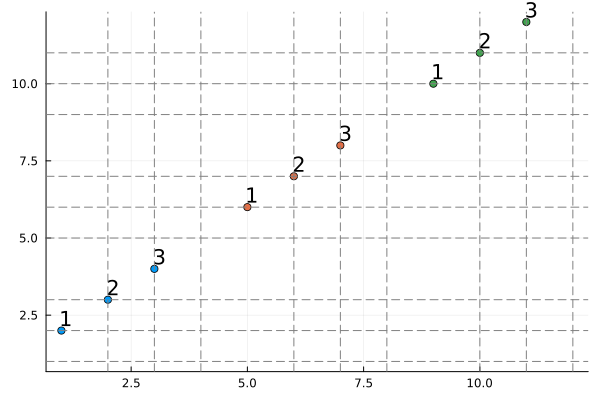

In [45]:
using Gridap
using Gridap.Geometry, Gridap.ReferenceFEs, Gridap.Arrays
using Plots

function plot_node_numbering(model)
    D = num_cell_dims(model)								# dimension (=2)
    topo = get_grid_topology(model)							# 
    node_coords = Geometry.get_node_coordinates(model)		# get the coordinates of the vertices of the cells as a Matrix (for 2D)
    cell_node_ids = get_cell_node_ids(model)				# get the ids (numbers) of the vertices of the cells
    cell_vertex_ids = Geometry.get_faces(topo, D, 0)		# vector of vertex ids (numbers) of the cells

    node_to_vertex = zeros(Int, length(node_coords))
    for (nodes, vertices) in zip(cell_node_ids, cell_vertex_ids)
        node_to_vertex[nodes] .= vertices
    end

    plot_node_numbering(cell_node_ids, node_to_vertex)
end

function plot_node_numbering(node_coords, node_ids)
    x = map(c -> c[1], node_coords)
    y = map(c -> c[2], node_coords)
    a = Plots.text.(node_ids, halign=:left, valign=:bottom)
    Plots.scatter(x, y, series_annotations=a, legend=false)
    hline!(unique(x), linestyle=:dash, color=:grey)
    vline!(unique(y), linestyle=:dash, color=:grey)
end
model2=CartesianDiscreteModel((-20,+20,-20,+20),(3,3))
plot_node_numbering(model2)

In [54]:
order = 1
reffe2 = ReferenceFE(lagrangian,Float64,order)
Testspace2 = TestFESpace(model2,reffe2,conformity=:H1,dirichlet_tags="boundary") ###### conformity correct?
Trialspace2 = TrialFESpace(Testspace2,0) 

testfuncev=interpolate_everywhere(1.0,Testspace2)
testfunc=interpolate(1.0,Testspace2)
trialfuncev=interpolate_everywhere(1.0,Trialspace2)
trialfunc=interpolate(1.0,Trialspace2)

@show(get_free_dof_values(testfuncev))
@show(get_free_dof_values(testfunc))
@show(get_free_dof_values(trialfuncev))
@show(get_free_dof_values(trialfunc))
@show(get_free_dof_ids(Testspace2))
@show(get_free_dof_ids(Trialspace2))
@show(get_node_coordinates(get_triangulation(testfunc)))

# function apply_indicator(u, indicator)
#     # Freie DOFs der FE-Funktion
# 	(t,uh)=first(u)
#     free_values = get_free_dof_values(uh)
    
#     # Koordinaten der Freiheitsgrade (DOFs) im FE-Raum
#     trian = get_triangulation(u[1][2])
#     node_coords = get_node_coordinates(trian)
#     free_dofs = get_free_dof_ids(Uspace)
    
#     # Maskierungsvektor erstellen
#     mask = zeros(length(free_values))
#     for (i, dof) in enumerate(free_dofs)
#         x = node_coords[dof]
#         mask[i] = indicator(x)
#     end
    
#     # Neue FEFunction mit maskierten Werten
#     new_free_values = free_values .* mask
#     return [(t,FEFunction(Uspace, new_free_values)) for (t, uh) in u]
# end

# get_node_coordinates(Ω)

get_free_dof_values(testfuncev) = [1.0, 1.0, 1.0, 1.0]
get_free_dof_values(testfunc) = [1.0, 1.0, 1.0, 1.0]
get_free_dof_values(trialfuncev) = [1.0, 1.0, 1.0, 1.0]
get_free_dof_values(trialfunc) = [1.0, 1.0, 1.0, 1.0]
get_free_dof_ids(Testspace2) = Base.OneTo(4)
get_free_dof_ids(Trialspace2) = Base.OneTo(4)
get_node_coordinates(get_triangulation(testfunc)) = VectorValue{2, Float64}[(-20.0, -20.0) (-20.0, -6.666666666666666) (-20.0, 6.666666666666668) (-20.0, 20.0); (-6.666666666666666, -20.0) (-6.666666666666666, -6.666666666666666) (-6.666666666666666, 6.666666666666668) (-6.666666666666666, 20.0); (6.666666666666668, -20.0) (6.666666666666668, -6.666666666666666) (6.666666666666668, 6.666666666666668) (6.666666666666668, 20.0); (20.0, -20.0) (20.0, -6.666666666666666) (20.0, 6.666666666666668) (20.0, 20.0)]


4×4 Gridap.Geometry.CartesianCoordinates{2, Float64, typeof(identity)}:
    VectorValue{2, Float64}(-20.0, -20.0)     VectorValue{2, Float64}(-20.0, -6.66667)  …     VectorValue{2, Float64}(-20.0, 20.0)
 VectorValue{2, Float64}(-6.66667, -20.0)  VectorValue{2, Float64}(-6.66667, -6.66667)     VectorValue{2, Float64}(-6.66667, 20.0)
  VectorValue{2, Float64}(6.66667, -20.0)   VectorValue{2, Float64}(6.66667, -6.66667)      VectorValue{2, Float64}(6.66667, 20.0)
     VectorValue{2, Float64}(20.0, -20.0)      VectorValue{2, Float64}(20.0, -6.66667)         VectorValue{2, Float64}(20.0, 20.0)

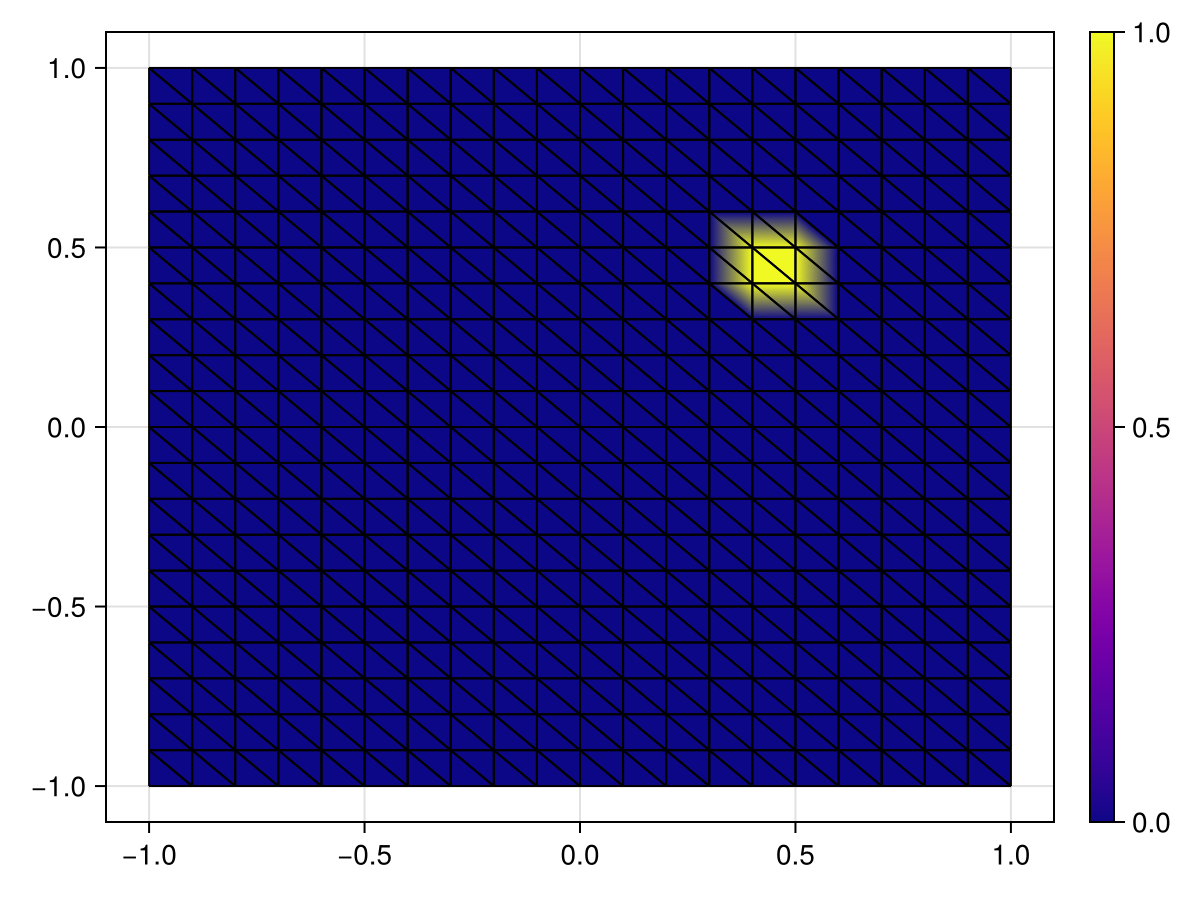

CairoMakie.Screen{IMAGE}


In [26]:
χ(x,a,b) = all(a .≤ x .≤ b) ? 1.0 : 0.0

χ([1,1],[0,0],[1,2])
Indikator(x)=χ(x,VectorValue([0.4,0.4]),VectorValue([0.6,0.6]))
Indikator(VectorValue([0.0,0.5]))
Ind=interpolate_everywhere(Indikator, Uspace(t0))
draw(Ind)

In [28]:
using Gridap
using GridapMakie
#using Makie

function 🌈(u;plotlabel="Temperature")
	fig = Figure(size=(800, 800))
	ax = Axis(fig[1,1], title="Time = 0.0")
	t0, u0 = u[1]
	plt = plot!(ax, Ω, u0, colormap=:viridis)
	Colorbar(fig[1,2], plt, label=plotlabel)
	print(u)
	min_T = min(min(collect(get_free_dof_values(uh))...) for (_, uh) in u)
	max_T = max(max(get_free_dof_values(uh)...) for (_, uh) in u)
	record(fig, "temperature_animation.mp4", 1:length(u)) do i
		t, uh = u[i]
		plt.input_args[1][] = uh  # Aktualisiere die Lösungsdaten
		ax.title = "Time = $(round(t, digits=2))"
		plt.colorrange = (min_T, max_T)
	end
end

#🌈(ps[1])
# min(get_free_dof_values(ps[1][1][2])...)

🌈 (generic function with 1 method)

In [60]:
using Dates

function savePVD(ys; dir=replace("$(now())",':' => '-'), vtkdir="", pvdfile="results")
	if !isdir("$dir/$vtkdir")
		mkdir("$dir/$vtkdir")
	end
	createpvd("$dir/$pvdfile") do pvd
		for (tn, uhn) in ys
			pvd[tn] = createvtk(Ω, "$dir/$vtkdir/$(pvdfile)_$tn.vtu", cellfields=["u" => uhn])
		end
	end
end

function savePVDall(vectorQs; dir=replace("$(now())",':' => '-'), folders=["cont","se","adj","grad"], files=["results_cont","results_se","results_adj","results_grad"])
	if !isdir("$dir")
		mkdir("$dir")
	end
	for (iter,Qs) in enumerate(vectorQs)
		for k = 1:length(Qs)
			savePVD(Qs[k]; dir="$dir", vtkdir="$(folders[iter])$(k)", pvdfile="$(files[iter])_$k")
		end
	end
end

savePVDall([Qs, Ts, Ws, gs])



In [ ]:
using Gridap
using Gridap
using GridapMakie, CairoMakie, FileIO
using Gridap.FESpaces
using Gridap.ReferenceFEs
using Gridap.Arrays
using Gridap.Algebra
using Gridap.Geometry
using Gridap.Fields
using Gridap.CellData
using FillArrays
using Test
using InteractiveUtils

function GradientDescent(;solveSE, solveAE, spaces, dΩ, dΓ=nothing, Q, J, ∇f, iter_max=1000, tol=1e-3, Proj=x->x, u0=nothing, w=nothing, s_min=nothing, sminargs=nothing, armijoparas=(ρ=1/2, α_0=1, α_min=1/2^5, σ=1e-4), Δt=0.05, t0=0.0, tF, saveall::Bool=false)
	Trialspace, Testspace, Qspace = spaces                                  # Extract spaces

	q = [(t,interpolate_everywhere(Q(t),Qspace(t))) for t=t0:Δt:tF]   
	qfun(t)=find(q,t)
	println("q computed")

	y, cacheSE, A_SE = solveSE(Q,Trialspace,Testspace,w=w,dΩ=dΩ,dΓ=dΓ)  # initial SE solve
	#y = FEFunction(Trialspace, y_dof)
	yfun(t) = find(y,t)

	p, cacheAE, A_AE = solveAE(yfun,q,Trialspace,Testspace,dΩ=dΩ,dΓ=dΓ)      # initial AE solve
	#p = FEFunction(Testspace, p_dof)
	println("p computed")

	cost = J(y, q)
	fgrad =  ∇f(q, p, y)														# Compute initial gradient
	L2fgrad_save = L2norm(fgrad)                                       # Compute norm of initial gradient

	if saveall
		qs=[q]                     # save the solutions - only if really necessary
		ys=[y]
		ps=[p]
		costs=[cost]
	else
		qs,ys,ps=[],[],[]
	end
	for k=1:iter_max
		println("entered for loop, E=$cost")
		q_new = y_new = cost_new = nothing
		if s_min!=nothing                                                   # if method for exact step size is defined use that
			s = s_min(y,q,w,p,sminargs=(cacheSE,A_SE,sminargs))
			q_new = interpolate_everywhere(q - s*fgrad,Qspace) |> P			# in most cases interpolate instead of interpolate_everywhere works as well
			y_dof, cacheSE = solveSE(q_new,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
			y_new = FEFunction(Trialspace, y_dof)
			cost_new = J(y,q)
		else                                                                # else use Armijo rule - if projection is used, you should consider smaller step size than default
			ρ, α_0, α_min, σ = armijoparas
			cost_new = cost
			L2fgrad = L2fgrad_save
			α = α_0
			while α > α_min
				println("entered while loop")
				
				
				q_new = [(t,interpolate_everywhere((qfun(t) - α*grad)*q_pos, Qspace(t))) for (t,grad) in fgrad]   # Compute tentative new control function defined by current line search parameter
				
				qfun=t->find(q_new,t)

				y_new, cacheSE = solveSE(qfun,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
				#y_new = FEFunction(Trialspace, y_dof)

				cost_new = J(y_new, q_new)                                  # Compare decrease in functional and accept if sufficient
				if cost_new < cost - σ*α*L2fgrad^2
					break
				else
                    # α = α_min #TEST!!
					α *= ρ
				end
			end
			if α <= α_min
				println("Armijo rule failed")
				break
			end

		end# here you could implement other methods
		println("Armoijo success")
		q = q_new
		y = y_new
		cost = cost_new
		
		if k % 10 == 0
			println("iteration: $k")
		end
		if saveall
			push!(qs,q)
			push!(ys,y)
			push!(costs,cost)
		end
		yfun=t->find(y,t)
		p, cacheAE = solveAE(yfun,q,Trialspace,Testspace;dΩ=dΩ,dΓ=dΓ)
		#p = FEFunction(Testspace, p_dof)

		fgrad = ∇f(q, p, y)
		L2fgrad = L2norm(fgrad)
		push!(ps,p)

		if L2fgrad < tol*L2fgrad_save                           # loop break condition - better ideas are appreciated
			break
		end

	end
	return saveall ? (ys,qs,ps,costs) : (y,q,p,cost)                    	# give back either all saved variables or only end result
end



function χ(x, a, b)
    if a < x && x < b
        return 1
    else
        return 0
    end
end

# Set parameters and run the solver
domain = (-1, +1, -1, +1)
partition = (20, 20)
order = 1
degree = 2
Δt = 0.01
θ = 0.5
solver = ThetaMethod(LUSolver(), Δt, θ)
t0, tF = 0.0, 1.0

model = CartesianDiscreteModel(domain, partition) |> simplexify #Koden fungerer ikke uten simplexify....????
reffe = ReferenceFE(lagrangian, Float64, order)
Testspace = TestFESpace(model, reffe, conformity=:H1)
Trialspace = TransientTrialFESpace(Testspace)

Ω = Triangulation(model)
dΩ = Measure(Ω, degree)
Γ = BoundaryTriangulation(model)
dΓ = Measure(Γ, degree)

Uspace = FESpace(model, reffe, conformity=:H1)



q_pos(x) = χ(x[1], -0.9, -0.7) * χ(x[2], 0, 0.20) + χ(x[1], 0.2, 0.4) * χ(x[2], -0.5, 0)
q(t) = x -> χ(t,0.0,1.0)*1000.0*q_pos(x)


Tout(t) = x -> 4.0



ρ(x)=1
c(x)=1
k(x)=1
h(x)=1
Toutdoor(x,t)=5.0
Tout(t)=x->Toutdoor(x,t)
Q(x,t)=χ(t,0.0,1.0)*1000.0*q_pos(x)
Qt(t)=x->Q(x,t)
price(t)=1.0
Tini(x)=20.0
t0=0.0
tF=1.0
TIni=interpolate_everywhere(Tini, Uspace(t0))
Tfin=interpolate_everywhere(20.0, Uspace(tF))
Δt = 0.05

γ = 1

function solveSE(Qt,Trialspace,Testspace;w=nothing,dΩ,dΓ=nothing,cache=nothing,A=nothing,y_dof=fill(0.0, num_free_dofs(Testspace)))
    
    α(t) = x -> 1.0
    m(t, dtu, v) = ∫(v * dtu)*dΩ
    a(t, u, v) = ∫(α(t) * ∇(v) ⋅ ∇(u))*dΩ + ∫(u * v)*dΓ
    l(t, v) = ∫(q_pos*v * Qt(t))* dΩ + ∫(Tout(t) * v)*dΓ
    
    SEop_opt = TransientLinearFEOperator((a, m), l, Trialspace, Testspace, constant_forms=(true, true))
    T0 = interpolate_everywhere(20.0, Trialspace(t0))
    T = solve(solver, SEop_opt, t0, tF, T0)

    return [[t0,T0],collect([t,TT] for (t,TT) in T)...], 0.0,0.0  

end

function solveAE(T,Q,Trialspace,Testspace;dΩ,dΓ=nothing,cache=nothing,A=nothing,W_dof=fill(0.0, num_free_dofs(Testspace)))
    α(t) = x -> 1.0
    m_AE(t, dtu, v) = ∫(v * dtu)dΩ
    a_AE(t, u, v) = ∫(α(t) * ∇(v) ⋅ ∇(u))dΩ + ∫(u*v)dΓ # +??
    l_AE(t, v) = ∫(0.0*v)dΩ

    AEop_opt = TransientLinearFEOperator((a_AE, m_AE), l_AE, Trialspace, Testspace, constant_forms=(true, true))

    W_end = interpolate_everywhere(T(tF)-20.0,Trialspace(tF))  
    W = solve(solver, AEop_opt, t0, tF, W_end)


	return [collect((tF-t,w) for (t,w) in reverse(collect((t,WW) for (t,WW) in W)))... ; (tF,W_end)], 0.0,0.0
end

function E(T,Q)
	E=0.0
	for (QQ,t) in Q
		E+=Δt*price(t)^2*γ*∑(∫(QQ*QQ)*dΩ)
	end
	tmp = last(T[1])-20
	E += γ* ∑(∫(tmp*tmp)*dΩ)
	# for (TT,t) in T
	# 	tmp=TT-20.0
	# 	E+=Δt*∑(∫(tmp*tmp)*dΩ) #The whole time?
	# 	println("Once")
	# end
	E = E/2.0
	return E
end
a = 0
b = 1000
Proj(a,b,z) = min(max(a,z),b)
# Proj(z) = map(x->Proj(a,b,x),z)

Proj(z) = [(t,FEFunction(Uspace,map(x->Proj(a,b,x), get_free_dof_values(zz)))) for (t,zz) in z]
# [(t,interpolate_everywhere(Uspace,map(x->Proj(a,b,x), Uspace(t)))) for (t,zz) in z]


∇e(Q::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}},
T::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}},
W::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}}) = [(Q[k][1],2*price(T[k][1])^2*Q[k][2]-W[k][2]) for k=1:length(Q)]                                                # gradient of reduced cost
function ∇e(Qt::Function,
T::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}},
W::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}})
	println(T)
	println(W)
	return collect((T[k][1],interpolate_everywhere(2*price(T[k][1])^2*Qt(T[k][1])-W[k][2],Uspace(T[k][1]))) for k=1:length(W))
end

function find(y,s)
	tsave,ysave=t0,nothing
	for (t,yy) in y
		ysave=yy
		break
	end
	for (t,yy) in y
		# if t≈t0
		# 	ysave=yy
		# 	tsave=t0
		# end
		if t≈s
			return yy
		elseif t ≥ s
			return interpolate_everywhere(((s-tsave)*ysave+(t-s)*yy)/Δt, Uspace(s))
		end
		tsave,ysave = t,yy
	end
end


function s_min(y,q,w,p;sminargs)
	cache,A=sminargs
	v=interpolate(-y*p+γ*q, Uspace)                                      # v=p+γ*u, since all uses of v are in norms we can ignore the minus
	Sv,_ = SEsolver(v,Trialspace,Testspace;dΩ=dΩ,cache=cache,A=A)
	Sv = FEFunction(Trialspace,Sv)
	L2NormSquaredOfv = ∑(∫(v*v)*dΩ)                                   # ||v||^2
	return L2NormSquaredOfv/(∑(∫(Sv*Sv)*dΩ)+γ*L2NormSquaredOfv)
end

L2norm(u)=√((tF-t0)*∑(Δt*∑(∫(uu⋅uu)*dΩ) for (t,uu) in u))

(ys,qs,ps,costs) = GradientDescent(;solveSE=solveSE, 
solveAE=solveAE, 
spaces=(Trialspace, Testspace, Uspace), 
dΩ=dΩ, 
dΓ=dΓ, 
Q=Qt, 
J=E, 
∇f=∇e, 
Proj=Proj, 
s_min=nothing,
sminargs=nothing, 
saveall=true, 
tol=1e-5, 
iter_max=4, 
armijoparas=(ρ=1/2, α_0=1, α_min=1/2^20, σ=1e-4), 
Δt=Δt, 
t0=t0, 
tF=tF)

q computed


MethodError: MethodError: no method matching (::var"#l#737"{Gridap.CellData.GenericMeasure, Gridap.CellData.GenericMeasure, typeof(Qt)})(::Gridap.FESpaces.SingleFieldFEBasis{Gridap.FESpaces.TestBasis, ReferenceDomain})

Closest candidates are:
  (::var"#l#737")(::Any, !Matched::Any)
   @ Main c:\NTNU\_Kurse TA\Optimierung 2\Experts in Teams Henning\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:175


In [44]:
get_node_coordinates(Ω)

441-element Vector{VectorValue{2, Float64}}:
                 VectorValue{2, Float64}(-1.0, -1.0)
                 VectorValue{2, Float64}(-0.9, -1.0)
                 VectorValue{2, Float64}(-0.8, -1.0)
                 VectorValue{2, Float64}(-0.7, -1.0)
                 VectorValue{2, Float64}(-0.6, -1.0)
                 VectorValue{2, Float64}(-0.5, -1.0)
  VectorValue{2, Float64}(-0.3999999999999999, -1.0)
 VectorValue{2, Float64}(-0.29999999999999993, -1.0)
 VectorValue{2, Float64}(-0.19999999999999996, -1.0)
 VectorValue{2, Float64}(-0.09999999999999998, -1.0)
                            ⋮
   VectorValue{2, Float64}(0.20000000000000018, 1.0)
   VectorValue{2, Float64}(0.30000000000000004, 1.0)
   VectorValue{2, Float64}(0.40000000000000013, 1.0)
                   VectorValue{2, Float64}(0.5, 1.0)
    VectorValue{2, Float64}(0.6000000000000001, 1.0)
    VectorValue{2, Float64}(0.7000000000000002, 1.0)
                   VectorValue{2, Float64}(0.8, 1.0)
    VectorValue{2, Float

In [ ]:
# Hilfsfunktion: Wendet die Indikatorfunktion auf eine FEFunction an
function apply_indicator(u, indicator)
    # Freie DOFs der FE-Funktion
	(t,uh)=first(u)
    free_values = get_free_dof_values(uh)
    
    # Koordinaten der Freiheitsgrade (DOFs) im FE-Raum
    trian = get_triangulation(u[1][2])
    node_coords = get_node_coordinates(trian)
    free_dofs = get_free_dof_ids(Uspace)
    
    # Maskierungsvektor erstellen
    mask = zeros(length(free_values))
    for (i, dof) in enumerate(free_dofs)
        x = node_coords[dof]
        mask[i] = indicator(x)
    end
    
    # Neue FEFunction mit maskierten Werten
    new_free_values = free_values .* mask
    return [(t,FEFunction(Uspace, new_free_values)) for (t, uh) in u]
end

function indicator(x)
    x₁, x₂ = x
    return (0.2 ≤ x₁ ≤ 0.4) && (-0.4 ≤ x₂ ≤ -0.4) ? 1.0 : 0.0
end

# 4. Indikator auf die FE-Funktion anwenden
uh_indicator = apply_indicator(Qs[end], indicator)

# 5. Ergebnisse exportieren
if !isdir("tmpq")
	mkdir("tmpq")
end
createpvd("results_q") do pvd
	for (tn, uhn) in Qs[end]
		pvd[tn] = createvtk(Ω, "tmpq/results_q_$tn" * ".vtu", cellfields=["u" => uhn])
	end
end
if !isdir("tmpqindicator")
	mkdir("tmpqindicator")
end
createpvd("results_qindicator") do pvd
	for (tn, uhn) in uh_indicator
		pvd[tn] = createvtk(Ω, "tmpqindicator/results_qindicator_$tn" * ".vtu", cellfields=["u" => uhn])
	end
end



22-element Vector{String}:
 "results_qindicator.pvd"
 "tmpqindicator/results_qindicator_0.0.vtu"
 "tmpqindicator/results_qindicator_0.05.vtu"
 "tmpqindicator/results_qindicator_0.1.vtu"
 "tmpqindicator/results_qindicator_0.15.vtu"
 "tmpqindicator/results_qindicator_0.2.vtu"
 "tmpqindicator/results_qindicator_0.25.vtu"
 "tmpqindicator/results_qindicator_0.3.vtu"
 "tmpqindicator/results_qindicator_0.35.vtu"
 "tmpqindicator/results_qindicator_0.4.vtu"
 ⋮
 "tmpqindicator/results_qindicator_0.6.vtu"
 "tmpqindicator/results_qindicator_0.65.vtu"
 "tmpqindicator/results_qindicator_0.7.vtu"
 "tmpqindicator/results_qindicator_0.75.vtu"
 "tmpqindicator/results_qindicator_0.8.vtu"
 "tmpqindicator/results_qindicator_0.85.vtu"
 "tmpqindicator/results_qindicator_0.9.vtu"
 "tmpqindicator/results_qindicator_0.95.vtu"
 "tmpqindicator/results_qindicator_1.0.vtu"

In [7]:
get_node_coordinates(get_triangulation(qs[end][1][2]))

441-element Vector{VectorValue{2, Float64}}:
                 VectorValue{2, Float64}(-1.0, -1.0)
                 VectorValue{2, Float64}(-0.9, -1.0)
                 VectorValue{2, Float64}(-0.8, -1.0)
                 VectorValue{2, Float64}(-0.7, -1.0)
                 VectorValue{2, Float64}(-0.6, -1.0)
                 VectorValue{2, Float64}(-0.5, -1.0)
  VectorValue{2, Float64}(-0.3999999999999999, -1.0)
 VectorValue{2, Float64}(-0.29999999999999993, -1.0)
 VectorValue{2, Float64}(-0.19999999999999996, -1.0)
 VectorValue{2, Float64}(-0.09999999999999998, -1.0)
                            ⋮
   VectorValue{2, Float64}(0.20000000000000018, 1.0)
   VectorValue{2, Float64}(0.30000000000000004, 1.0)
   VectorValue{2, Float64}(0.40000000000000013, 1.0)
                   VectorValue{2, Float64}(0.5, 1.0)
    VectorValue{2, Float64}(0.6000000000000001, 1.0)
    VectorValue{2, Float64}(0.7000000000000002, 1.0)
                   VectorValue{2, Float64}(0.8, 1.0)
    VectorValue{2, Float

## Nonsquared version with strict $\geq$ condition

In [ ]:
using Gridap
using GridapMakie, CairoMakie, FileIO
using Gridap.FESpaces
using Gridap.ReferenceFEs
using Gridap.Arrays
using Gridap.Algebra
using Gridap.Geometry
using Gridap.Fields
using Gridap.CellData
using FillArrays
using Test
using InteractiveUtils

function GradientDescent(;solveSE, solveAE, spaces, dΩ, dΓ=nothing, Q_ini, E, ∇e, iter_max=1000, tol=1e-3, P=x->x, u0=nothing, w=nothing, s_min=nothing, sminargs=nothing, armijoparas=(ρₐᵣₘᵢⱼₒ=1/2, α_0ₐᵣₘᵢⱼₒ=1, α_minₐᵣₘᵢⱼₒ=1/2^5, σₐᵣₘᵢⱼₒ=1e-4), Δt=0.05, t0=0.0, tF, Tini, Tfin, Tout, saveall::Bool=false)
	#=
	Solves any CP with possibly box bounds
	Input: (all are named arguments - order does not matter, but they have to be called by name)
	  solveSE   - a method to solve the SE, Input: u (rhs), Trialspace, Testspace. optional: dΩ, dΓ, cache from earlier execution, y_dof pre-solution in vector-form to write on. Output: solution, cache
	  solve AE  - a method to solve the AE, Input: y (rhs), Trialspace, Testspace. optional: dΩ, dΓ, cache from earlier execution, p_dof pre-solution in vector-form to write on. Output: solution, cache
	  spaces    - tuple of (trial space, test space, FE space)
	  dΩ        - measure on Ω
	  dΓ        - measure on ∂Ω=Γ (optional)
	  J         - functional to minimise (only needed for early breaking out of loop)
	  ∇f        - functional to compute gradient of reduced cost f
	  iter_max  - number of maximum iterations (default 2000)
	  tol       - tolerance for early break out of loop (default 10^(-3))
	  P         - Projection onto box. P is assumed to have the form u↦P(u) and should be able to handle an FEFunction as input (default without) and give such as output
	  u0        - start function for u (optional, default without)
	  w         - boundary term (default without)
	  s_min     - function to compute exact step size (default without - then Armijo rule will be used). Input is supposed to be y,u,w,p (from algorithm) and sminargs will be unloaded
	  sminargs  - additional arguments for s_min that can be given
	  armijoparas   - parameters for Armijo rule. defaults are given and can individually be changed (named arguments)
	=#
	Trialspace, Testspace, Qspace = spaces                                  # Extract spaces
	
	Q = [(t,interpolate(Q_ini(t),Qspace(t))) for t=t0:Δt:tF]
	Qfun(t)=find(Q,t)
	println("Q computed")

	T = solveSE(Q_ini,t0,tF,Tini,Tout,Trialspace,Testspace,w=w,dΩ=dΩ,dΓ=dΓ)  # initial SE solve
	#y = FEFunction(Trialspace, y_dof)
	Tfun(t)=find(T,t)
	println("T computed")

	W = solveAE(Tfun,t0,tF,Tfin,Trialspace,Testspace,dΩ=dΩ,dΓ=dΓ)      # initial AE solve
	#p = FEFunction(Testspace, p_dof)
	println("W computed")
	
	cost = E(T,Q)
	egrad =  ∇e(Q, T, W)														# Compute initial gradient
	L2egrad_save = L2norm(egrad)                                       # Compute norm of initial gradient

	if saveall
		Qs=[Q]                     # save the solutions - only if really necessary
		Ts=[T]
		Ws=[W]
		gs=[egrad]
		costs=[cost]
	else
		Qs,Ts,Ws,gs=[],[],[],[]
	end
	# try
	for k=1:iter_max
		println("entered for loop, E=$cost")
		Q_new = T_new = cost_new = Qfunnew = nothing
		if s_min!=nothing                                                   # if method for exact step size is defined use that
			s = s_min(Q,T,W,egrad;solveSE=solveSE, solveAE=solveAE, spaces=spaces, w=w, dΩ=dΩ, dΓ=dΓ, Δt=Δt, t0=t0, tF=tF)
			println("s_min = $s")
			Q_new = [(t,interpolate(Qfun(t) + s*grad, Qspace(t))) for (t,grad) in egrad] #|> Proj interpolate_everywhere(q - s*fgrad,Qspace) |> P			# in most cases interpolate instead of interpolate_everywhere works as well
			Qfunnew=t->find(Q_new,t)
			T_new = solveSE(Qfunnew,t0,tF,Tini,Tout,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
			#y_new = FEFunction(Trialspace, y_dof)
			cost_new = E(T_new,Q_new)
		else                                                                # else use Armijo rule - if projection is used, you should consider smaller step size than default
			ρₐᵣₘᵢⱼₒ, α_0ₐᵣₘᵢⱼₒ, α_minₐᵣₘᵢⱼₒ, σₐᵣₘᵢⱼₒ = armijoparas
			cost_new = cost
			L2egrad = L2egrad_save
			αₐᵣₘᵢⱼₒ = α_0ₐᵣₘᵢⱼₒ
			while αₐᵣₘᵢⱼₒ > α_minₐᵣₘᵢⱼₒ
				Q_new = [(t,interpolate(Qfun(t) - αₐᵣₘᵢⱼₒ*grad, Qspace(t))) for (t,grad) in egrad] #|> Proj    # Compute tentative new control function defined by current line search parameter
				Qfunnew=t->find(Q_new,t)

				T_new = solveSE(Qfunnew,t0,tF,Tini,Tout,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
				#y_new = FEFunction(Trialspace, y_dof)

				cost_new = E(T_new, Q_new)                                  # Compare decrease in functional and accept if sufficient
				if cost_new < cost #- σₐᵣₘᵢⱼₒ*αₐᵣₘᵢⱼₒ*L2egrad
					break
				else
					αₐᵣₘᵢⱼₒ *= ρₐᵣₘᵢⱼₒ
				end
			end
			if αₐᵣₘᵢⱼₒ <= α_minₐᵣₘᵢⱼₒ
				println("Armijo rule failed")
				break
			end
		end# here you could implement other methods
		Q = Q_new
		T = T_new
		Qfun = Qfunnew
		cost = cost_new
		
		if k % 10 == 0
			println("iteration: $k,   cost = $cost")
		end
		if saveall
			push!(Qs,Q)
			push!(Ts,T)
			push!(costs,cost)
		end
		Tfun=t->find(T,t)
		W = solveAE(Tfun,t0,tF,Tfin,Trialspace,Testspace;dΩ=dΩ,dΓ=dΓ)
		#p = FEFunction(Testspace, p_dof)

		egrad = ∇e(Q, T, W)
		L2egrad = L2norm(egrad)
		push!(Ws,W)
		push!(gs,egrad)

		if L2egrad < tol*L2egrad_save                           # loop break condition - better ideas are appreciated
			break
		end
	end
	# catch e
	# 	println("Error in for loop")
	# 	return saveall ? (Ts,Qs,Ws,gs,costs) : (T,Q,W,egrad,cost)
	# end
	return saveall ? (Ts,Qs,Ws,gs,costs) : (T,Q,W,egrad,cost)                    	# give back either all saved variables or only end result
end

function draw(ysol)
	fig, _ , plt = CairoMakie.plot(Ω, ysol, colormap=:plasma)               # plot of last state (numerical solution)
	CairoMakie.wireframe!(Ω, color=:black, linewidth=1)                        # add triangulation
	CairoMakie.Colorbar(fig[1,2], plt)                                         # add color bar
	display(fig)															  # display the plot
end


domain = (-20,+20,-20,+20)
partition = (20,20)
model = CartesianDiscreteModel(domain,partition) |> simplexify
order = 1
reffe = ReferenceFE(lagrangian,Float64,order)
Testspace = TestFESpace(model,reffe,conformity=:H1) ###### conformity correct?
Trialspace = TransientTrialFESpace(Testspace)                                # maybe add a function for/if Dirichlet conditions

Uspace = FESpace(model, reffe, conformity=:H1)

degree = 2*order                                                    # degree of the method used for approximating integrals over Ω
Ω = Triangulation(model)
dΩ = Measure(Ω,degree)                                              # make the measure dΩ
Γ = BoundaryTriangulation(model)                                    # triangulate the boundary ∂Ω
dΓ = Measure(Γ,degree)                                              # measure on Γ

χ(x,a,b;g::Function=x->x) = a≤x≤b ? g(x) : 0# all(a .≤ [xx for xx in x] .≤ b) ? g(x) : 0.0
q_pos(x) = χ(x[1], -0.9, -0.7) * χ(x[2], 0, 0.20) + χ(x[1], 0.2, 0.4) * χ(x[2], -0.5, 0)#χ(x, [-0.9, 0], [-0.7, 0.2])  + χ(x, [0.2, -0.5], [0.4, 0])
ρ(x)=1.225*1000
c(x)=1020.0
k(x)=15.0*1000
h(x)=0.7*1000
Toutdoor(x,t)=5.0
Tout(t)=x->Toutdoor(x,t)
Q(x,t)=χ(t,0.0,1.0)*1000.0*q_pos(x)
Qt(t)=x->Q(x,t)
price(t)=1.0#0.0303333*(t/3600)^5-0.392083*(t/3600)^4+1.71417*(t/3600)^3-3.02292*(t/3600)^2+2.4105*(t/3600)+2.95
Tini(x)=10.0
t0=0.0
tF=10.0
TIni=interpolate(Tini, Uspace(t0))
Tfin=interpolate(20.0, Uspace(tF))
Δt = 0.1

Proj(a,b,z) = min(max(a,z),b)
# Proj(z) = map(x->Proj(a,b,x),z)
a=0.0
b=1000.0*1000
Proj(z) = z#[[t,FEFunction(Uspace,map(x->Proj(a,b,x), get_free_dof_values(zz)))] for (t,zz) in z]
# [(t,interpolate_everywhere(map(x->P(a,b,x),get_free_dof_values(zz)),Uspace(t))) for (t,zz) in z]

γ = 100000
function E(T,Q)
	E=0.0
	for (t,QQ) in Q
		E+=price(t)*∑(∫(QQ)*dΩ)
	end
	E*=Δt
	# for (TT,t) in T
	# 	tmp=TT-20.0
	# 	E+=Δt*∑(∫(tmp*tmp)*dΩ)
	# end
	return E/2
end

# const kinv1 = TensorValue(1.0,0.0,0.0,1.0)
# const kinv2 = TensorValue(100.0,90.0,90.0,100.0)
# function σ(x,u)
#    if ((abs(x[1]-0.5) <= 0.1) && (abs(x[2]-0.5) <= 0.1))
#       return kinv2⋅u
#    else
#       return kinv1⋅u
#    end
# end

# px = get_physical_coordinate(trian)

function ∇e(Q::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}},T,W)
	return [(Q[k][1],price(Q[k][1])-ρ*W[k][2]*c) for k=1:length(Q)]                                                # gradient of reduced cost
end
function ∇e(Qt::Function,
T,
W)
	println(T)
	println(W)
	return collect((T[k][1],interpolate(price(T[k][1])-ρ*W[k][2]*c,Uspace(T[k][1]))) for k=1:length(W))
end

function find(y,s)
	tsave,ysave=t0,nothing
	for (t,yy) in y
		ysave=yy
		break
	end
	for (t,yy) in y
		# if t≈t0
		# 	ysave=yy
		# 	tsave=t0
		# end
		if t≈s
			return yy
		elseif t ≥ s
			return interpolate(((s-tsave)*ysave+(t-s)*yy)/Δt, Uspace(s))
		end
		tsave,ysave = t,yy
	end
end

L2norm(u)=√((tF-t0)*∑(Δt*∑(∫(uu⋅uu)*dΩ) for (t,uu) in u))
L2skp(u)=(tF-t0)*∑(Δt*∑(∫(uu⋅uu)*dΩ) for (t,uu) in u)
ls = LUSolver()
θ = 0.5
solver = ThetaMethod(ls, Δt, θ)


function SEsolver(Qt,t0,tF,Tini,Tout,Trialspace,Testspace;w=nothing,dΩ,dΓ=nothing,cache=nothing,A=nothing,y_dof=fill(0.0, num_free_dofs(Testspace)))
	a_SE_tconst(t, dtT, ϕ) = ∫(c*dtT*ϕ*ρ)dΩ
	a_SE_tnonconst(t, T, ϕ) = ∫(k * ∇(T)⋅∇(ϕ))dΩ + ∫(h*T*ϕ)dΓ
	l_SE(t, ϕ) = ∫(Qt(t) * ϕ)dΩ + ∫(Tout(t) * ϕ * h)dΓ	
	op_SE = TransientLinearFEOperator((a_SE_tnonconst, a_SE_tconst), l_SE, Trialspace, Testspace, constant_forms=(true, true))
	# tableau = :SDIRK_2_2
	# solver_rk = RungeKutta(ls, ls, Δt, tableau)

	T = solve(solver, op_SE, t0, tF, Tini)
	return [(t0,TIni),collect((t,FEFunction(Trialspace(t),copy(get_free_dof_values(TT)))) for (t,TT) in T)...]
end
function AEsolver(T,t0,tF,Tfin,Trialspace,Testspace;dΩ,dΓ=nothing,cache=nothing,A=nothing,W_dof=fill(0.0, num_free_dofs(Testspace)))
	a_AE_tconst(t, dtW, ψ) = ∫(c*dtW*ψ*ρ)dΩ
	a_AE_tnonconst(t, W, ψ) = ∫(k * (∇(W) ⋅ ∇(ψ)))dΩ - ∫(h*W*ψ)dΓ
	l_AE(t, ψ) = ∫(0.0*ψ)dΩ
	#l_AE(t, ψ) = γ*∫(((x->T(x,t))-Tfin)*ψ - tr(h*(x->Tout(x,t))*ψ))dΩ	
	op_AE = TransientLinearFEOperator((a_AE_tnonconst, a_AE_tconst), l_AE, Trialspace, Testspace, constant_forms=(true, true))
	# tableau = :SDIRK_2_2
	# solver_rk = RungeKutta(ls, ls, Δt, tableau)
	W_end=interpolate(-γ*(T(tF)-Tfin)/c/ρ, Uspace(tF))
	W = solve(ThetaMethod(LUSolver(), Δt, θ), op_AE, t0, tF, W_end)
	return [collect((tF-t,FEFunction(Trialspace(tF-t),w)) for (t,w) in reverse(collect((t,copy(get_free_dof_values(WW))) for (t,WW) in W)))... ; (tF,W_end)]
end


## Lastly we want to use the remark from the lecture and construct a solver function for the optimal step length. (see my extra remark)
function s_min(Q,T,W,gradient;solveSE, solveAE, spaces, w=nothing, dΩ, dΓ=nothing, s_ini=nothing, Δt=0.05, t0=0.0, tF)
	Trialspace, Testspace, FEspace = spaces
	gradfun(t)=find(gradient,t)
	Sv = solveSE(gradfun,t0,tF,TIni,Tout,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
	L2NormSquaredOfv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu)*dΩ) for (t,uu) in gradient)                                 # ||v||^2
	L2NormSquaredSv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu)*dΩ) for (t,uu) in Sv)
	L2NormSquaredpv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu*price*price)*dΩ) for (t,uu) in gradient)
	return -L2NormSquaredOfv/(2*(L2NormSquaredpv+γ/2*L2NormSquaredSv)) # -s_min because originally v=-∇e but calculating this costs much more time
end

(Ts,Qs,Ws,gs,costs) = GradientDescent(;solveSE=SEsolver, 
solveAE=AEsolver, 
spaces=(Trialspace, Testspace, Uspace), 
dΩ=dΩ, 
dΓ=dΓ, 
Q_ini=Qt, 
E=E, 
∇e=∇e, 
P=Proj, 
s_min=nothing,
sminargs=nothing, 
saveall=true, 
tol=1e-5, 
iter_max=10, 
armijoparas=(ρₐᵣₘᵢⱼₒ=1/2, α_0ₐᵣₘᵢⱼₒ=100, α_minₐᵣₘᵢⱼₒ=1/2^50, σₐᵣₘᵢⱼₒ=1e-4), 
Δt=0.1, 
t0=t0,
tF=tF,
Tini=TIni,
Tfin=Tfin,
Tout=Tout)

## Multifield Version

In [ ]:
using Gridap
using Gridap
using GridapMakie, CairoMakie, FileIO
using Gridap.FESpaces
using Gridap.ReferenceFEs
using Gridap.Arrays
using Gridap.Algebra
using Gridap.Geometry
using Gridap.Fields
using Gridap.CellData
using FillArrays
using Test
using InteractiveUtils

function χ(x, a, b)
    if a < x && x < b
        return 1
    else
        return 0
    end
end

# Set parameters and run the solver
domain = (-1, +1, -1, +1)
partition = (20, 20)
order = 1
degree = 2
Δt = 0.01
θ = 0.5
solver = ThetaMethod(LUSolver(), Δt, θ)
t0, tF = 0.0, 1.0

model = CartesianDiscreteModel(domain, partition) |> simplexify #Koden fungerer ikke uten simplexify....????
reffe = ReferenceFE(lagrangian, Float64, order)
SETestspace = TestFESpace(model, reffe, conformity=:H1)
AETestspace = TestFESpace(model, reffe, conformity=:H1)
VITestspace = TestFESpace(model, reffe, conformity=:H1)
MultiTestspace = MultiFieldFESpace([SETestspace, AETestspace, VITestspace])
SETrialspace = TransientTrialFESpace(SETestspace)
AETrialspace = TransientTrialFESpace(AETestspace)
VITrialspace = TransientTrialFESpace(VITestspace)
MultiTrialspace = MultiFieldFESpace([SETrialspace, AETrialspace, VITrialspace])

Ω = Triangulation(model)
dΩ = Measure(Ω, degree)
Γ = BoundaryTriangulation(model)
dΓ = Measure(Γ, degree)








ρ(x)=1
c(x)=1
k(x)=1
h(x)=1
q_pos(x) = χ(x[1], -0.9, -0.7) * χ(x[2], 0, 0.20) + χ(x[1], 0.2, 0.4) * χ(x[2], -0.5, 0)
Tout(t) = x -> 4.0
Q(x,t)=χ(t,0.0,1.0)*1000.0*q_pos(x)
Qt(t)=x->Q(x,t)
price(t)=1.0
Tini(x)=20.0
t0=0.0
tF=1.0
TIni=interpolate_everywhere(Tini, Uspace(t0))
Tfin=interpolate_everywhere(20.0, Uspace(tF))
Δt = 0.05

γ = 1

a(t,(Q,T,W),(θ,ϕ,ψ))=∫( (c*∂t(T)*ϕ*ρ)+k*∇(T) ⋅ ∇(ϕ) - Q*ϕ  +  c*∂t(W)*ψ*ρ + k*(∇(W) ⋅ ∇(ψ))  +  (2*price*price*Q-ρ*c*W)*θ)*dΩ + ∫( h*(T*ϕ - W*ψ) )dΓ 
l(t,(θ,ϕ,ψ)) = ∫(Tout(t) * ϕ * h)dΓ 
op=TransientLinearFEOperator(a,l,MultiTrialspace,MultiTestspace,constant_forms=(true, true)) #(a,m)??
QTW=solve(ThetaMethod(LUSolver(), Δt, 0.5),op,t0,t_F,............) Ini?? TIni, 
W_end=interpolate_everywhere(-γ*(T(tF)-Tfin)/c/ρ, Uspace(tF))

function AEsolver(T,Q,Trialspace,Testspace;dΩ,dΓ=nothing,cache=nothing,A=nothing,W_dof=fill(0.0, num_free_dofs(Testspace)))
	
	#l_AE(t, ψ) = γ*∫(((x->T(x,t))-Tfin)*ψ - tr(h*(x->Tout(x,t))*ψ))dΩ	
	op_AE = TransientLinearFEOperator((a_AE_tnonconst, a_AE_tconst), l_AE, Trialspace, Testspace, constant_forms=(true, true))
	# tableau = :SDIRK_2_2
	# solver_rk = RungeKutta(ls, ls, Δt, tableau)
	
	W = solve(, op_AE, t0, tF, W_end)
	return [collect([tF-t,w] for (t,w) in reverse(collect((t,WW) for (t,WW) in W)))... ; [tF,W_end]], 0.0,0.0
end

function solveSE(Qt,Trialspace,Testspace;w=nothing,dΩ,dΓ=nothing,cache=nothing,A=nothing,y_dof=fill(0.0, num_free_dofs(Testspace)))
    
    α(t) = x -> 1.0
    m(t, dtu, v) = ∫(v * dtu)*dΩ
    a(t, u, v) = ∫(α(t) * ∇(v) ⋅ ∇(u))*dΩ + ∫(u * v)*dΓ
    l(t, v) = ∫(q_pos*v * Qt(t))* dΩ + ∫(Tout(t) * v)*dΓ
    
    SEop_opt = TransientLinearFEOperator((a, m), l, Trialspace, Testspace, constant_forms=(true, true))
    T0 = interpolate_everywhere(20.0, Trialspace(t0))
    T = solve(solver, SEop_opt, t0, tF, T0)

    return [(t0,T0),collect((t,TT) for (t,TT) in T)...], 0.0,0.0  

end

function solveAE(T,Q,Trialspace,Testspace;dΩ,dΓ=nothing,cache=nothing,A=nothing,W_dof=fill(0.0, num_free_dofs(Testspace)))
    α(t) = x -> 1.0
    m_AE(t, dtu, v) = ∫(v * dtu)dΩ
    a_AE(t, u, v) = ∫(α(t) * ∇(v) ⋅ ∇(u))dΩ + ∫(u*v)dΓ # +??
    l_AE(t, v) = ∫(0.0*v)dΩ

    AEop_opt = TransientLinearFEOperator((a_AE, m_AE), l_AE, Trialspace, Testspace, constant_forms=(true, true))

    W_end = interpolate_everywhere(T(tF)-20.0,Trialspace(tF))  
    W = solve(solver, AEop_opt, t0, tF, W_end)


	return [collect((tF-t,w) for (t,w) in reverse(collect((t,WW) for (t,WW) in W)))... ; (tF,W_end)], 0.0,0.0
end

function E(T,Q)
	E=0.0
	for (QQ,t) in Q
		E+=Δt*price(t)^2*γ*∑(∫(QQ*QQ)*dΩ)
	end
	tmp = last(T[1])-20
	E += γ* ∑(∫(tmp*tmp)*dΩ)
	# for (TT,t) in T
	# 	tmp=TT-20.0
	# 	E+=Δt*∑(∫(tmp*tmp)*dΩ) #The whole time?
	# 	println("Once")
	# end
	E = E/2.0
	return E
end
a = 0
b = 1000
Proj(a,b,z) = min(max(a,z),b)
# Proj(z) = map(x->Proj(a,b,x),z)

Proj(z) = [(t,FEFunction(Uspace,map(x->Proj(a,b,x), get_free_dof_values(zz)))) for (t,zz) in z]
# [(t,interpolate_everywhere(Uspace,map(x->Proj(a,b,x), Uspace(t)))) for (t,zz) in z]


# ∇e(Q::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}},
# T::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}},
# W::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}}) = [(Q[k][1],2*price(T[k][1])^2*Q[k][2]-W[k][2]) for k=1:length(Q)]                                                # gradient of reduced cost
# function ∇e(Qt::Function,
# T::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}},
# W::Vector{Tuple{Float64, SingleFieldFEFunction{GenericCellField{ReferenceDomain}}}})
# 	println(T)
# 	println(W)
# 	return collect((T[k][1],interpolate_everywhere(2*price(T[k][1])^2*Qt(T[k][1])-W[k][2],Uspace(T[k][1]))) for k=1:length(W))
# end



# function s_min(y,q,w,p;sminargs)
# 	cache,A=sminargs
# 	v=interpolate(-y*p+γ*q, Uspace)                                      # v=p+γ*u, since all uses of v are in norms we can ignore the minus
# 	Sv,_ = SEsolver(v,Trialspace,Testspace;dΩ=dΩ,cache=cache,A=A)
# 	Sv = FEFunction(Trialspace,Sv)
# 	L2NormSquaredOfv = ∑(∫(v*v)*dΩ)                                   # ||v||^2
# 	return L2NormSquaredOfv/(∑(∫(Sv*Sv)*dΩ)+γ*L2NormSquaredOfv)
# end

L2norm(u)=√((tF-t0)*∑(Δt*∑(∫(uu⋅uu)*dΩ) for (t,uu) in u))

(ys,qs,ps,costs) = GradientDescent(;solveSE=solveSE, 
solveAE=solveAE, 
spaces=(Trialspace, Testspace, Uspace), 
dΩ=dΩ, 
dΓ=dΓ, 
Q=Qt, 
J=E, 
∇f=∇e, 
Proj=Proj, 
s_min=nothing,
sminargs=nothing, 
saveall=true, 
tol=1e-5, 
iter_max=4, 
armijoparas=(ρ=1/2, α_0=1, α_min=1/2^20, σ=1e-4), 
Δt=Δt, 
t0=t0, 
tF=tF)

## Multifield $t=x_{n+1}$ Version

In [ ]:
using Gridap
using GridapMakie, CairoMakie, FileIO
using Gridap.FESpaces
using Gridap.ReferenceFEs
using Gridap.Arrays
using Gridap.Algebra
using Gridap.Geometry
using Gridap.Fields
using Gridap.CellData
using FillArrays
using Test
using InteractiveUtils

function draw(ysol)
	fig, _ , plt = CairoMakie.plot(Ω, ysol, colormap=:plasma)               # plot of last state (numerical solution)
	CairoMakie.wireframe!(Ω, color=:black, linewidth=1)                        # add triangulation
	CairoMakie.Colorbar(fig[1,2], plt)                                         # add color bar
	display(fig)															  # display the plot
end

t0, tF=0.0, 10.0
Δt = 0.05
model = CartesianDiscreteModel((-1,+1,-1,+1,t0,tF),(20,20,ceil(Int,(tF-t0)/Δt))) |> simplexify
order = 1
reffe = ReferenceFE(lagrangian,Float64,order)
Testspace = TestFESpace(model,reffe,conformity=:H1) ###### conformity correct?
Trialspace = TransientTrialFESpace(Testspace)                                # maybe add a function for/if Dirichlet conditions

Uspace = FESpace(model, reffe, conformity=:H1)


SETestspace = TestFESpace(model, reffe, conformity=:H1)
AETestspace = TestFESpace(model, reffe, conformity=:H1)
VITestspace = TestFESpace(model, reffe, conformity=:L2)
MultiTestspace = MultiFieldFESpace([SETestspace, AETestspace, VITestspace])
SETrialspace = TransientTrialFESpace(SETestspace)
AETrialspace = TransientTrialFESpace(AETestspace)
VITrialspace = TransientTrialFESpace(VITestspace)
MultiTrialspace = MultiFieldFESpace([SETrialspace, AETrialspace, VITrialspace])

degree = 2*order                                                    # degree of the method used for approximating integrals over Ω
Ω = Triangulation(model)
dΩ = Measure(Ω,degree)                                              # make the measure dΩ
Γ = BoundaryTriangulation(model)                                    # triangulate the boundary ∂Ω
dΓ = Measure(Γ,degree)                                              # measure on Γ

χ(x,a,b;g::Function=x->x) = a≤x≤b ? g(x) : 0# all(a .≤ [xx for xx in x] .≤ b) ? g(x) : 0.0
q_pos(x) = χ(x[1], -0.9, -0.7) * χ(x[2], 0, 0.20) + χ(x[1], 0.2, 0.4) * χ(x[2], -0.5, 0)#χ(x, [-0.9, 0], [-0.7, 0.2])  + χ(x, [0.2, -0.5], [0.4, 0])
ρ(x)=1.225
c(x)=1020.0
k(x)=15.0
h(x)=0.7
Toutdoor(x,t)=5.0
Tout(t)=x->Toutdoor(x,t)
Q(x,t)=χ(t,0.0,1.0)*1000.0*q_pos(x)
Qt(t)=x->Q(x,t)
price(t)=1.0
Tini(x)=20.0
TIni=interpolate(Tini, Uspace(t0))
Tfin=interpolate(20.0, Uspace(tF))

Proj(a,b,z) = min(max(a,z),b)
# Proj(z) = map(x->Proj(a,b,x),z)
a=0.0
b=1000.0
Proj(z) = [[t,FEFunction(Uspace,map(x->Proj(a,b,x), get_free_dof_values(zz)))] for (t,zz) in z]
# [(t,interpolate_everywhere(map(x->P(a,b,x),get_free_dof_values(zz)),Uspace(t))) for (t,zz) in z]

γ = 1000
function E(T,Q)
	E=0.0
	for (t,QQ) in Q
		E+=price(t)^2*∑(∫(QQ*QQ)*dΩ)
	end
	E*=Δt
	tmp=last(T)[2]-Tfin
	E+=γ*∑(∫(tmp*tmp)*dΩ)
	# for (TT,t) in T
	# 	tmp=TT-20.0
	# 	E+=Δt*∑(∫(tmp*tmp)*dΩ)
	# end
	return E
end

# const kinv1 = TensorValue(1.0,0.0,0.0,1.0)
# const kinv2 = TensorValue(100.0,90.0,90.0,100.0)
# function σ(x,u)
#    if ((abs(x[1]-0.5) <= 0.1) && (abs(x[2]-0.5) <= 0.1))
#       return kinv2⋅u
#    else
#       return kinv1⋅u
#    end
# end

# px = get_physical_coordinate(trian)



L2norm(u)=√((tF-t0)*∑(Δt*∑(∫(uu⋅uu)*dΩ) for (t,uu) in u))
L2skp(u)=(tF-t0)*∑(Δt*∑(∫(uu⋅uu)*dΩ) for (t,uu) in u)
ls = LUSolver()
θ = 0.5
solver = ThetaMethod(ls, Δt, θ)


function SEsolver(Qt,t0,tF,Tini,Tout,Trialspace,Testspace;w=nothing,dΩ,dΓ=nothing,cache=nothing,A=nothing,y_dof=fill(0.0, num_free_dofs(Testspace)))
	a_SE_tconst(t, dtT, ϕ) = ∫(c*dtT*ϕ*ρ)dΩ
	a_SE_tnonconst(t, T, ϕ) = ∫(k * ∇(T)⋅∇(ϕ))dΩ + ∫(h*T*ϕ)dΓ
	l_SE(t, ϕ) = ∫(Qt(t) * ϕ)dΩ + ∫(Tout(t) * ϕ * h)dΓ	
	op_SE = TransientLinearFEOperator((a_SE_tnonconst, a_SE_tconst), l_SE, Trialspace, Testspace, constant_forms=(true, true))
	# tableau = :SDIRK_2_2
	# solver_rk = RungeKutta(ls, ls, Δt, tableau)

	T = solve(solver, op_SE, t0, tF, Tini)
	return [(t0,TIni),collect((t,FEFunction(Trialspace(t),copy(get_free_dof_values(TT)))) for (t,TT) in T)...]
end
function AEsolver(T,t0,tF,Tfin,Trialspace,Testspace;dΩ,dΓ=nothing,cache=nothing,A=nothing,W_dof=fill(0.0, num_free_dofs(Testspace)))
	a_AE_tconst(t, dtW, ψ) = ∫(c*dtW*ψ*ρ)dΩ
	a_AE_tnonconst(t, W, ψ) = ∫(k * (∇(W) ⋅ ∇(ψ)))dΩ - ∫(h*W*ψ)dΓ
	l_AE(t, ψ) = ∫(0.0*ψ)dΩ
	#l_AE(t, ψ) = γ*∫(((x->T(x,t))-Tfin)*ψ - tr(h*(x->Tout(x,t))*ψ))dΩ	
	op_AE = TransientLinearFEOperator((a_AE_tnonconst, a_AE_tconst), l_AE, Trialspace, Testspace, constant_forms=(true, true))
	# tableau = :SDIRK_2_2
	# solver_rk = RungeKutta(ls, ls, Δt, tableau)
	W_end=interpolate(-γ*(T(tF)-Tfin)/c/ρ, Uspace(tF))
	W = solve(ThetaMethod(LUSolver(), Δt, θ), op_AE, t0, tF, W_end)
	return [collect((tF-t,FEFunction(Trialspace(tF-t),w)) for (t,w) in reverse(collect((t,copy(get_free_dof_values(WW))) for (t,WW) in W)))... ; (tF,W_end)]
end


## Lastly we want to use the remark from the lecture and construct a solver function for the optimal step length. (see my extra remark)
function s_min(Q,T,W,gradient;solveSE, solveAE, spaces, w=nothing, dΩ, dΓ=nothing, s_ini=nothing, Δt=0.05, t0=0.0, tF)
	Trialspace, Testspace, FEspace = spaces
	gradfun(t)=find(gradient,t)
	Sv = solveSE(gradfun,t0,tF,TIni,Tout,Trialspace,Testspace;w=w,dΩ=dΩ,dΓ=dΓ)
	L2NormSquaredOfv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu)*dΩ) for (t,uu) in gradient)                                 # ||v||^2
	L2NormSquaredSv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu)*dΩ) for (t,uu) in Sv)
	L2NormSquaredpv = (tF-t0)*Δt*∑(∑(∫(uu⋅uu*price*price)*dΩ) for (t,uu) in gradient)
	return -L2NormSquaredOfv/(2*(L2NormSquaredpv+γ/2*L2NormSquaredSv)) # -s_min because originally v=-∇e but calculating this costs much more time
end

(Ts,Qs,Ws,costs) = GradientDescent(;solveSE=SEsolver, 
solveAE=AEsolver, 
spaces=(Trialspace, Testspace, Uspace), 
dΩ=dΩ, 
dΓ=dΓ, 
Q_ini=Qt, 
E=E, 
∇e=∇e, 
P=Proj, 
s_min=nothing,
sminargs=nothing, 
saveall=true, 
tol=1e-5, 
iter_max=10, 
armijoparas=(ρ=1/2, α_0=100, α_min=1/2^50, σ=1e-4), 
Δt=0.05, 
t0=t0,
tF=tF,
Tini=TIni,
Tfin=Tfin,
Tout=Tout)

In [8]:
get_face_labeling(model)

FaceLabeling:
 0-faces: 441
 1-faces: 1240
 2-faces: 800
 tags: 10
 entities: 9

In [7]:
get_face_tag(get_face_labeling(model),1)

1240-element Vector{Int8}:
 5
 7
 9
 9
 9
 5
 9
 9
 9
 5
 ⋮
 9
 9
 6
 9
 9
 6
 9
 8
 6

In [10]:
get_node_coordinates(Ω)

441-element Vector{VectorValue{2, Float64}}:
                 VectorValue{2, Float64}(-1.0, -1.0)
                 VectorValue{2, Float64}(-0.9, -1.0)
                 VectorValue{2, Float64}(-0.8, -1.0)
                 VectorValue{2, Float64}(-0.7, -1.0)
                 VectorValue{2, Float64}(-0.6, -1.0)
                 VectorValue{2, Float64}(-0.5, -1.0)
  VectorValue{2, Float64}(-0.3999999999999999, -1.0)
 VectorValue{2, Float64}(-0.29999999999999993, -1.0)
 VectorValue{2, Float64}(-0.19999999999999996, -1.0)
 VectorValue{2, Float64}(-0.09999999999999998, -1.0)
                            ⋮
   VectorValue{2, Float64}(0.20000000000000018, 1.0)
   VectorValue{2, Float64}(0.30000000000000004, 1.0)
   VectorValue{2, Float64}(0.40000000000000013, 1.0)
                   VectorValue{2, Float64}(0.5, 1.0)
    VectorValue{2, Float64}(0.6000000000000001, 1.0)
    VectorValue{2, Float64}(0.7000000000000002, 1.0)
                   VectorValue{2, Float64}(0.8, 1.0)
    VectorValue{2, Float

In [9]:
get_labels(model)

UndefVarError: UndefVarError: `get_labels` not defined

In [35]:
using Gridap, Optim

# Problemparameter
κ = 1.0  # Wärmeleitfähigkeit
h = 1.0  # Wärmeübergangskoeffizient
λ = 1.0  # Gewichtung der Endtemperatur
Nx, Nt = 50, 100  # Diskretisierung in Raum und Zeit
L, T_final = 1.0, 1.0  # Länge des Intervalls und Endzeitpunkt
dx, dt = L / (Nx - 1), T_final / (Nt - 1)

# Erstelle das Gitter für Gridap
domain = (0,L)
partition = (Nx - 1,)
model = CartesianDiscreteModel(domain, partition)

# Definiere die Funktionräume
Ω = Triangulation(model)
dΩ = Measure(Ω, 2)
V = TestFESpace(model, ReferenceFE(lagrangian, Float64, 1), conformity=:H1, dirichlet_tags="boundary")
U = TrialFESpace(V)

# Anfangs- und Randbedingungen
T_ini(x) = sin(π * x[1])  # Beispielhafte Anfangsbedingung
T_fin(x) = 0.0  # Gewünschte Endtemperatur
Preis(t) = exp(-t)  # Kostenfunktion für Heizung
T_ext = 0.0  # Außentemperatur

# Zielfunktion
def objective(Q_vec)
    Q = interpolate(Q_vec, U)
    T_old = interpolate(T_ini, U)
    T = interpolate(T_ini, U)

    for n in 1:Nt
        a(u,v) = ∫(κ * ∇(u) ⋅ ∇(v) + u*v/dt) * dΩ
        l(v) = ∫((T_old/dt + Q) * v) * dΩ
        T = solve(FEOperator(a, l, U, V))
        T_old = T
    end

    J1 = sum((Preis.(range(0,T_final,length=Nt)).^2) .* sum(Q^2) * dx * dt)
    J2 = λ * sum((T - T_fin).^2) * dx
    return J1 + J2
end

# Optimierung
Q0 = zeros(Nx)  # Startwert für Q
res = optimize(objective, Q0, NelderMead())
Q_opt = res.minimizer

println("Optimierung erfolgreich: ", res.converged)

ErrorException: invalid redefinition of constant Main.h

## Simplex

In [ ]:
using JuMP
using HiGHS, Ipopt

χ(x,a,b;g::Function=x->x) = a≤x≤b ? g(x) : 0# all(a .≤ [xx for xx in x] .≤ b) ? g(x) : 0.0
q_pos(x) = χ(x[1], -0.9, -0.7) * χ(x[2], 0, 0.20) + χ(x[1], 0.2, 0.4) * χ(x[2], -0.5, 0)#χ(x, [-0.9, 0], [-0.7, 0.2])  + χ(x, [0.2, -0.5], [0.4, 0])
ρ(x)=1.225
c(x)=1020.0
k(x)=15
∇k(x)=[0.0,0.0]
h(x)=0.7
Toutdoor(x,t)=5.0
Tout(t)=x->Toutdoor(x,t)
Q_max=100000.0
price(t)=1#0.0303333*(t/3600)^5-0.392083*(t/3600)^4+1.71417*(t/3600)^3-3.02292*(t/3600)^2+2.4105*(t/3600)+2.95
Tini(x)=10.0
Tfin(x)=20.0

xa, xb, ya, yb = -1.0, 1.0, -1.0, 1.0
t0, tf= 0.0, 10/3600*3600.0 # 1 a.m. to 7 a.m. in seconds
Δt = 1.0
Δx = 0.1
Δy = 0.1

model = Model(Ipopt.Optimizer)
set_string_names_on_creation(model, false)
lx,ly,lt = Int(round((xb-xa)/Δx)), Int(round((yb-ya)/Δy)), Int(round((tf-t0)/Δt))
if !((xb-xa)/Δx ≈ lx) || !((yb-ya)/Δy ≈ ly) || !((tf-t0)/Δt ≈ lt)
	println("step lengths do not divide the domain")
end
println("lx, ly, lt = $lx, $ly, $lt")
@variable(model, QQ[i=0:lx,j=0:ly,s=0:lt] >=0, start=Q_max)
@variable(model, T[0:lx,0:ly,0:lt])
# set_start_value(Q[:,:,:], Q_max)
function E(Q)
	E=AffExpr(0.0)
	add_to_expression!(E,price(0)/2*(1/4*(Q[0,0,0]+Q[lx,0,0]+Q[0,ly,0]+Q[lx,ly,0]) + sum(1/2*(Q[0,j,0] .+ Q[lx,j,0])  +  sum(Q[i,j,0] for i=1:lx-1) for j=1:ly-1)))
	add_to_expression!(E,price(tf)/2*(1/4*(Q[0,0,lt]+Q[lx,0,lt]+Q[0,ly,lt]+Q[lx,ly,lt]) + sum(1/2*(Q[0,j,lt] .+ Q[lx,j,lt])  +  sum(Q[i,j,lt] for i=1:lx-1) for j=1:ly-1)))
	for s=1:lt-1
		t= t0+s*Δt
		add_to_expression!(E,price(t)/4*(Q[0,0,s]+Q[lx,0,s]+Q[0,ly,s]+Q[lx,ly,s]))
		add_to_expression!(E,price(t)*sum(1/2*(Q[0,j,s] .+ Q[lx,j,s])  +  sum(Q[i,j,s] for i=1:lx-1) for j=1:ly-1))
	end
	return E*Δt*Δx*Δy
end
@objective(model,Min,E(QQ)) #Δx*Δy*Δt*sum(1/2^count([i==0||i=lx , j==0||j=ly , s==0||s=lt])*QQ[i,j,s] for i=0:lx,j=0:ly,s=0:lt)
for i=1:lx-1
	x=xa+i*Δx
    for j=1:ly-1
		y=ya+j*Δy
		for s=1:lt-1
			t= t0+s*Δt
			@constraint(model, ρ([x,y])*c([x,y])*(T[i,j,s]-T[i,j,s-1])/(Δt) == (∇k([x,y])[1]*(T[i+1,j,s]-T[i-1,j,s])/(2Δx) + ∇k([x,y])[2]*(T[i,j+1,s]-T[i,j-1,s])/(2*Δy)) + k([x,y])*((T[i+1,j,s]+T[i-1,j,s]-2*T[i,j,s])/Δx^2+(T[i,j+1,s]+T[i,j-1,s]-2*T[i,j,s])/Δy^2)+QQ[i,j,s] )
		end
		@constraint(model, ρ([x,y])*c([x,y])*(T[i,j,lt]-T[i,j,lt-1])/Δt == (∇k([x,y])[1]*(T[i+1,j,lt]-T[i-1,j,lt]) + ∇k([x,y])[2]*(T[i,j+1,lt]-T[i,j-1,lt]))/(2*Δy) + k([x,y])*(T[i+1,j,lt]+T[i-1,j,lt]+T[i,j+1,lt]+T[i,j-1,lt]-4*T[i,j,lt])/Δx^2+QQ[i,j,lt] )
    end
end
for j=1:ly-1
	y=ya+j*Δx
	for s=1:lt-1
		t= t0+s*Δt
		@constraint(model, -k([xb,y])*(T[lx,j,s]-T[lx-1,j,s])/Δx == h([xb,y])*(T[lx,j,s]-Toutdoor([xb,y],t)))
		@constraint(model, k([xa,y])*(T[1,j,s]-T[0,j,s])/Δx == h([xa,y])*(T[0,j,s]-Toutdoor([xa,y],t)))
	end
end
for i=1:lx-1
	x=xa+i*Δx
	for s=1:lt-1
		t= t0+s*Δt
		@constraint(model, -k([x,yb])*(T[i,ly,s]-T[i,ly-1,s])/Δy == h([x,yb])*(T[i,ly,s]-Toutdoor([x,yb],t)))
		@constraint(model, k([x,ya])*(T[i,1,s]-T[i,0,s])/Δy == h([x,ya])*(T[i,0,s]-Toutdoor([x,ya],t)))
	end
end
for i=0:lx
	x=xa+i*Δx
	for j=0:ly
		y=ya+j*Δy
		@constraint(model, T[i,j,0] == Tini([x,y]))
		@constraint(model, T[i,j,lt] >= Tfin([x,y]))
		for s=1:lt
			t= t0+s*Δt
			@constraint(model, T[i,j,s] >= Toutdoor([x,y],t))
		end
	end
end

optimize!(model)

In [ ]:
value.(T)

In [14]:
exts

(-304.89585779286284, 151602.21722661308)

┌ Info: Saved animation to c:\NTNU\_Kurse TA\Optimierung 2\Experts in Teams Henning\2025-04-02T03-17-58.001_SimplexSolution.gif
└ @ Plots C:\Users\paulschm\.julia\packages\Plots\3u4B6\src\animation.jl:156


Plots.AnimatedGif("c:\\NTNU\\_Kurse TA\\Optimierung 2\\Experts in Teams Henning\\2025-04-02T03-17-58.001_SimplexSolution.gif")
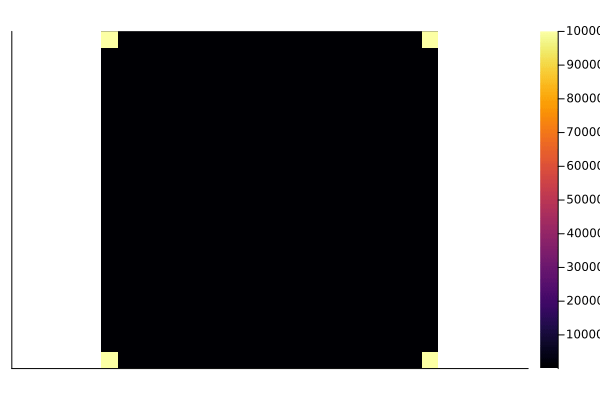

In [27]:
using Plots, Dates

exts=extrema(value.(T[:,:,:]))

pp = heatmap(collect(value.(T[:,:,0])),clim=exts,aspect_ratio=1,xticks=false,yticks=false)
p=plot(pp)
anim = @animate for s=1:lt
	heatmap(pp,collect(value.(T[:,:,s])),clim=exts,xticks=false,yticks=false)
end
gif(anim,"$(replace("$(now())",':' => '-'))_SimplexSolution.gif", fps=max(5,Int(1/Δt)))


In [16]:
value.(QQ)

3-dimensional DenseAxisArray{Float64,3,...} with index sets:
    Dimension 1, 0:20
    Dimension 2, 0:20
    Dimension 3, 0:10
And data, a 21×21×11 Array{Float64, 3}:
[:, :, 0] =
      1.99472e-6  9.92361e-7  9.92361e-7  …  9.92361e-7       1.99472e-6
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
 100000.0         4.91181e-7  4.91181e-7  …  4.91181e-7  100000.0
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
      ⋮                                   ⋱                   ⋮
 100000.0         4.91181e-7  4.91181e-7     4.91181e-7  100000.0
 100000.0         4.9118

In [ ]:
value.(QQ) # wtf? Solutions for Q seem to have a core with same value, a boundary with higher and nearly equal value and are zero close to the boundary. I'm bad at modelling....

3-dimensional DenseAxisArray{Float64,3,...} with index sets:
    Dimension 1, 0:20
    Dimension 2, 0:20
    Dimension 3, 0:2
And data, a 21×21×3 Array{Float64, 3}:
[:, :, 0] =
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱ 

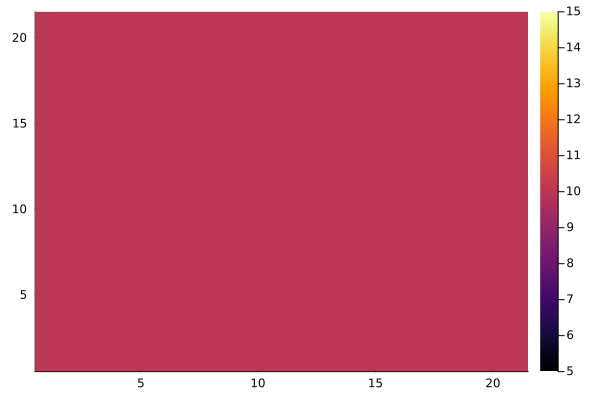

In [23]:
heatmap(collect(value.(T[:,:,0])),clim=(5,15))

In [25]:
TTTSimp=collect(value.(T[:,:,:]))
QQQSimp=collect(value.(QQ[:,:,:]))

22×22×102 Array{Float64, 3}:
[:, :, 1] =
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱  ⋮                        ⋮    
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  

In [23]:
value(TTTSimp[1,1,1])

10.0

## Solve with InfiniteOpt

In [ ]:
using InfiniteOpt, Ipopt

h(x)=0.7
Toutdoor(x,t)=5.0
Tout(t)=x->Toutdoor(x,t)
Q_max=100000.0
price(t)=1#0.0303333*(t/3600)^5-0.392083*(t/3600)^4+1.71417*(t/3600)^3-3.02292*(t/3600)^2+2.4105*(t/3600)+2.95
Tini(x)=10.0
Tfin(x)=20.0

xa, xb, ya, yb = -1.0, 1.0, -1.0, 1.0
t0, tf= 0.0, 10/3600*3600.0 # 1 a.m. to 7 a.m. in seconds
Δt = 1.0
Δx = 0.1
Δy = 0.1

model = InfiniteModel(Ipopt.Optimizer)
@infinite_parameter(model, x ∈ [xa, xb], num_supports = 21, derivative_method = OrthogonalCollocation(2))
@infinite_parameter(model, y ∈ [ya, yb], num_supports = 21, derivative_method = OrthogonalCollocation(2))
@infinite_parameter(model, t ∈ [t0, tf], num_supports = 51, derivative_method = OrthogonalCollocation(2))
ρ(x,y)=1.225
c(x,y)=1020.0
k(x,y)=15
∇k(x,y)=[0.0,0.0]
@variable(model, Q ≥ 0, Infinite(x, y, t)) #start=Q_max
@variable(model, T, Infinite(x, y, t))
@objective(model, Min, ∫(∫(∫(Q, x), y), t))
@constraint(model, Ini, T(x,y,t0)==Tini([x,y])) #initial_condition
@constraint(model,  ρ(x,y)*c(x,y)*∂(T,t) == (∇k(x,y)[1]*∂(T,x) + ∇k(x,y)[2]*∂(T,y)) + k(x,y)*(∂(∂(T,x),x)+∂(∂(T,y),y))+Q )
@constraint(model, Robin, -k(x,y)*∂(T,x) == h(x,y)*(T(x,y,t)-Toutdoor([x,y],t))) #right_boundary_condition
@constraint(model, Final, T(x,y,tf) >= Tfin([x,y])) #final_condition

optimize!(model)

┌ Warning: Due to necessarily considering the combinatorics of independent parameter supports, the model will be transcripted over up to 25168 supports (if any constraint uses all the infinite parameters) and thus naive solution of the discretized problem may be slow. This warning can be turned off via `check_support_dims = false`.
└ @ InfiniteOpt.TranscriptionOpt C:\Users\paulschm\.julia\packages\InfiniteOpt\2oc8E\src\TranscriptionOpt\transcribe.jl:955


This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:   413595
Number of nonzeros in inequality constraint Jacobian.:      441
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:   157437
                     variables with only lower bounds:    22491
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:   130662
Total number of inequality constraints...............:      441
        inequality constraints with only lower bounds:      441
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  3.9999960e-01 2.00e+01 1.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 